In [1]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    for file in files[:10]:
        print("   ", file)

/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/shl-hiring-assessment-2026
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final
    sample_submission.csv
    train.csv
    test.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test
    audio_49.wav
    audio_90.wav
    audio_77.wav
    audio_66.wav
    audio_54.wav
    audio_42.wav
    audio_81.wav
    audio_72.wav
    audio_107.wav
    audio_79.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train
    audio_49.wav
    audio_663.wav
    audio_5059.wav
    audio_90.wav
    audio_581.wav
    audio_698.wav
    audio_77.wav
    audio_66.wav
    audio_555.wav
    audio_54.wav


In [2]:
import pandas as pd

DATA_PATH = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"

train = pd.read_csv(f"{DATA_PATH}/train.csv")
test = pd.read_csv(f"{DATA_PATH}/test.csv")
sample_submission = pd.read_csv(f"{DATA_PATH}/sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

print("\n--- TRAIN ---")
display(train.head())

print("\n--- TEST ---")
display(test.head())

print("\n--- SAMPLE SUBMISSION ---")
display(sample_submission.head())

print("\nTrain columns:", train.columns.tolist())
print("Test columns:", test.columns.tolist())
print("Submission columns:", sample_submission.columns.tolist())

Train shape: (769, 2)
Test shape: (216, 2)
Sample submission shape: (204, 2)

--- TRAIN ---


,filename,label
0,audio_192.wav,3.0
1,audio_436.wav,3.0
2,audio_447.wav,3.5
3,audio_126.wav,2.0
4,audio_61.wav,2.0



--- TEST ---


,filename,label
0,audio_128.wav,-1
1,audio_156.wav,-1
2,audio_19.wav,-1
3,audio_108.wav,-1
4,audio_206.wav,-1



--- SAMPLE SUBMISSION ---


,filename,label
0,audio_804.wav,-1
1,audio_1028.wav,-1
2,audio_865.wav,-1
3,audio_774.wav,-1
4,audio_1138.wav,-1



Train columns: ['filename', 'label']
Test columns: ['filename', 'label']
Submission columns: ['filename', 'label']


In [3]:
print("=== TEST INFO ===")
print(test.tail(10))
print("\nTest label values:")
print(test["label"].value_counts())

print("\n=== SAMPLE SUBMISSION INFO ===")
print(sample_submission.head(10))
print(sample_submission.tail(10))

print("\nSample submission columns:")
print(sample_submission.columns.tolist())

print("\nSample submission filename count:", len(sample_submission))
print("Test filename count:", len(test))

print("\nTest filenames missing from sample submission:")
print(set(test["filename"]) - set(sample_submission["filename"]))

print("\nSample submission filenames not in test:")
print(set(sample_submission["filename"]) - set(test["filename"]))

=== TEST INFO ===
          filename  label
206   audio_20.wav     -1
207  audio_124.wav     -1
208   audio_54.wav     -1
209   audio_45.wav     -1
210   audio_71.wav     -1
211  audio_184.wav     -1
212   audio_24.wav     -1
213  audio_140.wav     -1
214  audio_165.wav     -1
215  audio_170.wav     -1

Test label values:
label
-1    216
Name: count, dtype: int64

=== SAMPLE SUBMISSION INFO ===
         filename  label
0   audio_804.wav     -1
1  audio_1028.wav     -1
2   audio_865.wav     -1
3   audio_774.wav     -1
4  audio_1138.wav     -1
5   audio_278.wav     -1
6  audio_1212.wav     -1
7   audio_178.wav     -1
8   audio_542.wav     -1
9   audio_248.wav     -1
           filename  label
194   audio_749.wav     -1
195   audio_978.wav     -1
196   audio_981.wav     -1
197   audio_563.wav     -1
198   audio_531.wav     -1
199   audio_787.wav     -1
200  audio_1079.wav     -1
201   audio_550.wav     -1
202   audio_641.wav     -1
203  audio_1001.wav     -1

Sample submission columns:
['

In [4]:
test_files = set(test["filename"])
submission_files = set(sample_submission["filename"])

print("Test files:", len(test_files))
print("Submission files:", len(submission_files))
print("Common files:", len(test_files & submission_files))

print("\nTest files NOT in submission:", len(test_files - submission_files))
print("Submission files NOT in test:", len(submission_files - test_files))

print("\nFirst 20 test files:")
print(sorted(test_files)[:20])

print("\nFirst 20 submission files:")
print(sorted(submission_files)[:20])

Test files: 216
Submission files: 204
Common files: 25

Test files NOT in submission: 191
Submission files NOT in test: 179

First 20 test files:
['audio_0.wav', 'audio_1.wav', 'audio_10.wav', 'audio_100.wav', 'audio_101.wav', 'audio_102.wav', 'audio_103.wav', 'audio_104.wav', 'audio_105.wav', 'audio_106.wav', 'audio_107.wav', 'audio_108.wav', 'audio_109.wav', 'audio_11.wav', 'audio_110.wav', 'audio_111.wav', 'audio_112.wav', 'audio_113.wav', 'audio_114.wav', 'audio_115.wav']

First 20 submission files:
['audio_1001.wav', 'audio_1006.wav', 'audio_1011.wav', 'audio_1025.wav', 'audio_1028.wav', 'audio_1039.wav', 'audio_1041.wav', 'audio_1046.wav', 'audio_1055.wav', 'audio_1059.wav', 'audio_1069.wav', 'audio_1079.wav', 'audio_108.wav', 'audio_1088.wav', 'audio_1090.wav', 'audio_1092.wav', 'audio_1099.wav', 'audio_1102.wav', 'audio_1104.wav', 'audio_1131.wav']


In [7]:
import os
import re

print("=== DATASET FOLDERS ===")

for item in os.listdir(DATA_PATH):
    full_path = os.path.join(DATA_PATH, item)
    if os.path.isdir(full_path):
        print(item, "-> folder")
    else:
        print(item, "-> file")


print("\n=== AUDIO COUNTS ===")

train_audio_path = os.path.join(DATA_PATH, "train")
test_audio_path = os.path.join(DATA_PATH, "test")

train_audio = [
    f for f in os.listdir(train_audio_path)
    if f.endswith(".wav")
]

test_audio = [
    f for f in os.listdir(test_audio_path)
    if f.endswith(".wav")
]

print("Train folder WAV files:", len(train_audio))
print("Test folder WAV files:", len(test_audio))


print("\n=== FILENAME RANGES ===")

def get_numbers(files):
    numbers = []

    for f in files:
        match = re.search(r"audio_(\d+)\.wav", f)

        if match:
            numbers.append(int(match.group(1)))

    return sorted(numbers)


train_ids = get_numbers(train_audio)
test_ids = get_numbers(test_audio)
submission_ids = get_numbers(sample_submission["filename"].tolist())

print("Train audio ID range:", min(train_ids), "to", max(train_ids))
print("Test audio ID range:", min(test_ids), "to", max(test_ids))
print("Submission ID range:", min(submission_ids), "to", max(submission_ids))


print("\n=== CSV/FOLDER CHECK ===")

print("Train CSV files:", len(train))
print("Train folder files:", len(train_audio))

print("Test CSV files:", len(test))
print("Test folder files:", len(test_audio))


print("\nTrain CSV filenames missing from train folder:")
print(set(train["filename"]) - set(train_audio))


print("\nTest CSV filenames missing from test folder:")
print(set(test["filename"]) - set(test_audio))

=== DATASET FOLDERS ===
sample_submission.csv -> file
train.csv -> file
test.csv -> file
test -> folder
train -> folder

=== AUDIO COUNTS ===
Train folder WAV files: 769
Test folder WAV files: 216

=== FILENAME RANGES ===
Train audio ID range: 0 to 5073
Test audio ID range: 0 to 215
Submission ID range: 13 to 1329

=== CSV/FOLDER CHECK ===
Train CSV files: 769
Train folder files: 769
Test CSV files: 216
Test folder files: 216

Train CSV filenames missing from train folder:
set()

Test CSV filenames missing from test folder:
set()


In [8]:
# Check whether sample submission audio files exist anywhere in Kaggle input

import os

submission_files = set(sample_submission["filename"])

found_files = []

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file in submission_files:
            found_files.append(os.path.join(root, file))

print("Submission audio files expected:", len(submission_files))
print("Submission audio files found:", len(found_files))

print("\nFirst 20 found files:")
for f in found_files[:20]:
    print(f)

Submission audio files expected: 204
Submission audio files found: 130

First 20 found files:
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_72.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_188.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_67.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_27.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_57.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_41.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_161.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_89.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_178.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_171.wav
/kaggle/input/competitions/shl-hiring-asse

In [9]:
import os
import soundfile as sf

print("=== SAMPLE AUDIO INFORMATION ===")

for filename in train["filename"].head(5):
    path = os.path.join(DATA_PATH, "train", filename)

    audio, sample_rate = sf.read(path)

    duration = len(audio) / sample_rate

    print(f"\nFile: {filename}")
    print(f"Sample rate: {sample_rate} Hz")
    print(f"Duration: {duration:.2f} seconds")
    print(f"Audio shape: {audio.shape}")

=== SAMPLE AUDIO INFORMATION ===

File: audio_192.wav
Sample rate: 16000 Hz
Duration: 60.51 seconds
Audio shape: (968134,)

File: audio_436.wav
Sample rate: 16000 Hz
Duration: 60.07 seconds
Audio shape: (961195,)

File: audio_447.wav
Sample rate: 16000 Hz
Duration: 60.07 seconds
Audio shape: (961195,)

File: audio_126.wav
Sample rate: 16000 Hz
Duration: 45.06 seconds
Audio shape: (720960,)

File: audio_61.wav
Sample rate: 16000 Hz
Duration: 45.30 seconds
Audio shape: (724800,)


In [10]:
import numpy as np
import pandas as pd
import librosa

from tqdm.auto import tqdm

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Librosa:", librosa.__version__)

NumPy: 2.1.3
Pandas: 2.3.3
Librosa: 0.11.0


In [11]:
import numpy as np
import librosa
import os

def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=16000, mono=True)

    features = {}

    # Basic audio information
    features["duration"] = len(y) / sr

    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

    for i in range(13):
        features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
        features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

    # Delta MFCC
    delta = librosa.feature.delta(mfcc)

    for i in range(13):
        features[f"delta_{i+1}_mean"] = np.mean(delta[i])
        features[f"delta_{i+1}_std"] = np.std(delta[i])

    # Spectral features
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    zero_crossing = librosa.feature.zero_crossing_rate(y)
    rms = librosa.feature.rms(y=y)

    features["spectral_centroid_mean"] = np.mean(spectral_centroid)
    features["spectral_centroid_std"] = np.std(spectral_centroid)

    features["spectral_bandwidth_mean"] = np.mean(spectral_bandwidth)
    features["spectral_bandwidth_std"] = np.std(spectral_bandwidth)

    features["spectral_rolloff_mean"] = np.mean(spectral_rolloff)
    features["spectral_rolloff_std"] = np.std(spectral_rolloff)

    features["zero_crossing_mean"] = np.mean(zero_crossing)
    features["zero_crossing_std"] = np.std(zero_crossing)

    features["rms_mean"] = np.mean(rms)
    features["rms_std"] = np.std(rms)

    return features


# Test on one training file
sample_file = train["filename"].iloc[0]
sample_path = os.path.join(DATA_PATH, "train", sample_file)

features = extract_features(sample_path)

print("File:", sample_file)
print("Number of features:", len(features))
print("\nFeatures:")

for name, value in features.items():
    print(f"{name}: {value:.4f}")

File: audio_192.wav
Number of features: 63

Features:
duration: 60.5084
mfcc_1_mean: -403.8359
mfcc_1_std: 121.6292
mfcc_2_mean: 103.5763
mfcc_2_std: 68.0357
mfcc_3_mean: -14.2135
mfcc_3_std: 37.1004
mfcc_4_mean: 16.6736
mfcc_4_std: 21.8437
mfcc_5_mean: 7.0486
mfcc_5_std: 11.1922
mfcc_6_mean: -4.9996
mfcc_6_std: 14.0739
mfcc_7_mean: 5.8857
mfcc_7_std: 10.0868
mfcc_8_mean: -9.2689
mfcc_8_std: 11.2389
mfcc_9_mean: -8.6811
mfcc_9_std: 9.1751
mfcc_10_mean: -6.1113
mfcc_10_std: 7.0058
mfcc_11_mean: -11.9470
mfcc_11_std: 8.7552
mfcc_12_mean: -8.2262
mfcc_12_std: 6.8835
mfcc_13_mean: -6.2382
mfcc_13_std: 5.7470
delta_1_mean: -0.0261
delta_1_std: 15.2939
delta_2_mean: -0.0142
delta_2_std: 8.9029
delta_3_mean: 0.0073
delta_3_std: 6.6618
delta_4_mean: -0.0019
delta_4_std: 4.0172
delta_5_mean: -0.0024
delta_5_std: 2.1264
delta_6_mean: 0.0045
delta_6_std: 2.4134
delta_7_mean: -0.0018
delta_7_std: 1.8824
delta_8_mean: -0.0052
delta_8_std: 1.7184
delta_9_mean: -0.0044
delta_9_std: 1.5896
delta_10_me

In [12]:
from tqdm.auto import tqdm
import pandas as pd
import os

# Extract features from training audio
train_features = []

for filename in tqdm(train["filename"], desc="Training audio"):
    path = os.path.join(DATA_PATH, "train", filename)

    try:
        features = extract_features(path)
        features["filename"] = filename
        train_features.append(features)

    except Exception as e:
        print(f"Error processing {filename}: {e}")


# Extract features from test audio
test_features = []

for filename in tqdm(test["filename"], desc="Test audio"):
    path = os.path.join(DATA_PATH, "test", filename)

    try:
        features = extract_features(path)
        features["filename"] = filename
        test_features.append(features)

    except Exception as e:
        print(f"Error processing {filename}: {e}")


# Convert to DataFrames
train_features = pd.DataFrame(train_features)
test_features = pd.DataFrame(test_features)

# Put filename first
train_features = train_features[
    ["filename"] + [c for c in train_features.columns if c != "filename"]
]

test_features = test_features[
    ["filename"] + [c for c in test_features.columns if c != "filename"]
]

print("\nTrain feature shape:", train_features.shape)
print("Test feature shape:", test_features.shape)

display(train_features.head())

Training audio:   0%|          | 0/769 [00:00<?, ?it/s]

Test audio:   0%|          | 0/216 [00:00<?, ?it/s]


Train feature shape: (769, 64)
Test feature shape: (216, 64)


,filename,duration,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,...,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,zero_crossing_mean,zero_crossing_std,rms_mean,rms_std
0,audio_192.wav,60.508375,-403.835907,121.629189,103.576340,68.035652,-14.213533,37.100353,16.673616,21.843693,...,979.478539,399.567888,916.472067,261.620566,1770.739688,661.667662,0.084768,0.053518,0.031786,0.038404
1,audio_436.wav,60.074688,-287.111023,81.685997,72.087601,56.021065,5.334722,46.173588,24.854349,37.073082,...,1813.837012,1156.460316,1502.301143,495.435560,3277.169030,1860.128111,0.142977,0.127519,0.068651,0.055423
2,audio_447.wav,60.074688,-324.808197,86.514740,97.828194,59.010967,18.635786,30.665184,5.857049,28.117016,...,1652.475254,1207.838332,1500.652559,535.214385,2941.260650,2078.460142,0.146870,0.129777,0.054421,0.051533
3,audio_126.wav,45.060000,-489.320648,124.842316,111.792915,53.296013,0.751575,41.733730,33.133247,33.229671,...,996.631363,471.566967,1177.252185,392.434373,1865.640525,1171.358114,0.059477,0.036870,0.013778,0.012183
4,audio_61.wav,45.300000,-483.865997,159.520401,51.975899,58.754555,-21.642136,44.306683,31.146597,36.615963,...,2278.144095,1068.412091,1630.415181,442.415960,4034.356241,1606.058056,0.169988,0.128430,0.009330,0.008970


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

# Merge audio features with grammar scores
train_data = train_features.merge(
    train[["filename", "label"]],
    on="filename",
    how="inner"
)

print("Training data shape:", train_data.shape)

# Separate features and target
X = train_data.drop(columns=["filename", "label"])
y = train_data["label"]

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

# Baseline model
model = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_features=0.8,
    min_samples_leaf=2
)

# Train
model.fit(X_train, y_train)

# Predictions
train_pred = model.predict(X_train)
val_pred = model.predict(X_val)

# Keep predictions within valid grammar-score range
train_pred = np.clip(train_pred, 0, 5)
val_pred = np.clip(val_pred, 0, 5)

# Metrics
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

train_pearson = pearsonr(y_train, train_pred)[0]
val_pearson = pearsonr(y_val, val_pred)[0]

print("\n===== BASELINE RESULTS =====")

print(f"Training RMSE:    {train_rmse:.4f}")
print(f"Validation RMSE:  {val_rmse:.4f}")

print(f"Training Pearson:   {train_pearson:.4f}")
print(f"Validation Pearson: {val_pearson:.4f}")

Training data shape: (769, 65)
Training samples: 615
Validation samples: 154

===== BASELINE RESULTS =====
Training RMSE:    0.0965
Validation RMSE:  0.7085
Training Pearson:   0.9980
Validation Pearson: 0.8536


Top 20 features:


,feature,importance
59,zero_crossing_mean,0.065102
30,delta_2_std,0.053619
4,mfcc_2_std,0.052524
1,mfcc_1_mean,0.049455
57,spectral_rolloff_mean,0.032397
53,spectral_centroid_mean,0.032091
32,delta_3_std,0.027936
34,delta_4_std,0.027628
6,mfcc_3_std,0.027331
42,delta_8_std,0.026870


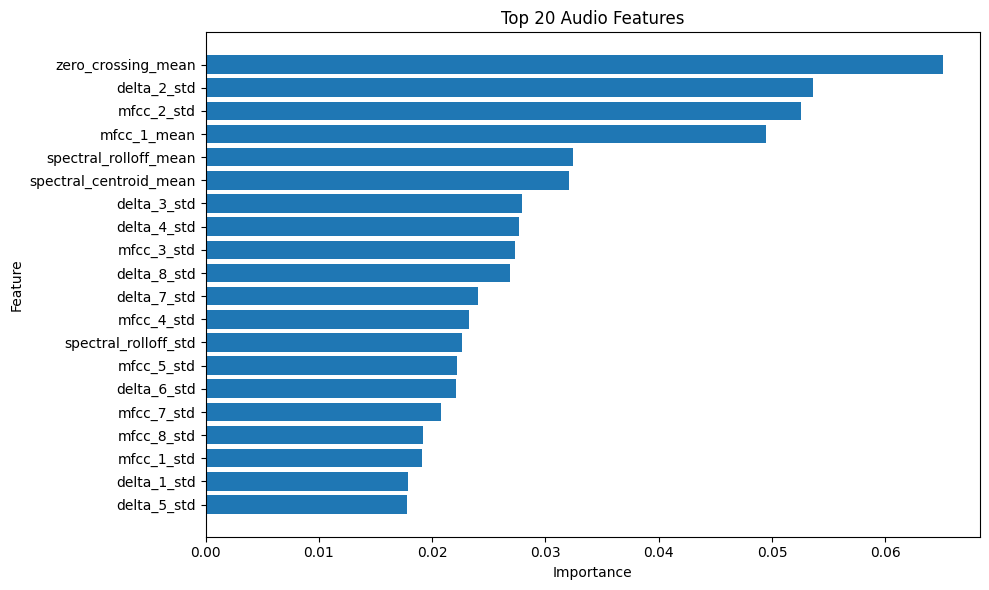

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 20 features:")
display(importance.head(20))

plt.figure(figsize=(10, 6))
plt.barh(
    importance.head(20)["feature"][::-1],
    importance.head(20)["importance"][::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Audio Features")
plt.tight_layout()
plt.show()

In [16]:
# Additional speech-pattern features
import numpy as np
import librosa

def extract_speech_features(file_path):
    y, sr = librosa.load(file_path, sr=16000, mono=True)

    features = {}

    # RMS energy
    rms = librosa.feature.rms(
        y=y,
        frame_length=2048,
        hop_length=512
    )[0]

    # Adaptive silence threshold
    threshold = max(np.percentile(rms, 20) * 1.5, 1e-4)

    silence = rms < threshold
    speech = ~silence

    # Speech / silence ratio
    features["speech_ratio"] = np.mean(speech)
    features["silence_ratio"] = np.mean(silence)

    # Number of silence segments
    silence_starts = np.sum(
        (silence[1:] == True) &
        (silence[:-1] == False)
    )

    features["num_silence_segments"] = silence_starts

    # Approximate pause duration
    silence_lengths = []
    current_length = 0

    for value in silence:
        if value:
            current_length += 1
        elif current_length > 0:
            silence_lengths.append(current_length)
            current_length = 0

    if current_length > 0:
        silence_lengths.append(current_length)

    if silence_lengths:
        silence_lengths = np.array(silence_lengths)

        features["avg_pause_duration"] = (
            np.mean(silence_lengths) * 512 / sr
        )

        features["max_pause_duration"] = (
            np.max(silence_lengths) * 512 / sr
        )

        features["pause_duration_std"] = (
            np.std(silence_lengths) * 512 / sr
        )
    else:
        features["avg_pause_duration"] = 0
        features["max_pause_duration"] = 0
        features["pause_duration_std"] = 0

    # Energy variation
    features["rms_mean"] = np.mean(rms)
    features["rms_std"] = np.std(rms)
    features["rms_median"] = np.median(rms)

    # Dynamic range of speech energy
    features["rms_p10"] = np.percentile(rms, 10)
    features["rms_p90"] = np.percentile(rms, 90)

    return features

In [18]:
# Test the new speech features on one audio file

sample_file = os.path.join(
    "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test",
    test["filename"].iloc[0]
)

speech_features = extract_speech_features(sample_file)

speech_features

{'speech_ratio': np.float64(0.7608232789212207),
 'silence_ratio': np.float64(0.23917672107877927),
 'num_silence_segments': np.int64(27),
 'avg_pause_duration': np.float64(0.3851428571428572),
 'max_pause_duration': np.float64(1.6),
 'pause_duration_std': np.float64(0.43688096730326526),
 'rms_mean': np.float32(0.018476367),
 'rms_std': np.float32(0.018032545),
 'rms_median': np.float32(0.015123016),
 'rms_p10': np.float32(0.00042277784),
 'rms_p90': np.float32(0.043261297)}

In [19]:
# Extract speech-pattern features for all training files

train_speech_features = []

for filename in train["filename"]:
    file_path = os.path.join(
        "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train",
        filename
    )

    features = extract_speech_features(file_path)
    features["filename"] = filename

    train_speech_features.append(features)

train_speech_features = pd.DataFrame(train_speech_features)

print("Training speech features shape:", train_speech_features.shape)
display(train_speech_features.head())

Training speech features shape: (769, 12)


,speech_ratio,silence_ratio,num_silence_segments,avg_pause_duration,max_pause_duration,pause_duration_std,rms_mean,rms_std,rms_median,rms_p10,rms_p90,filename
0,0.695928,0.304072,32,0.557576,3.616,0.713937,0.031786,0.038404,0.014546,0.000250,0.089015,audio_192.wav
1,0.732694,0.267306,83,0.191238,1.600,0.250268,0.068651,0.055423,0.064333,0.007004,0.120406,audio_436.wav
2,0.763578,0.236422,39,0.355200,2.464,0.423248,0.054421,0.051533,0.043020,0.001581,0.126990,audio_447.wav
3,0.753016,0.246984,41,0.271610,1.408,0.307024,0.013778,0.012183,0.010709,0.000787,0.029996,audio_126.wav
4,0.774718,0.225282,25,0.392615,2.176,0.423744,0.009330,0.008970,0.007482,0.000027,0.021658,audio_61.wav


In [20]:
# Extract speech-pattern features for all test files

test_speech_features = []

for filename in test["filename"]:
    file_path = os.path.join(
        "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test",
        filename
    )

    features = extract_speech_features(file_path)
    features["filename"] = filename

    test_speech_features.append(features)

test_speech_features = pd.DataFrame(test_speech_features)

print("Test speech features shape:", test_speech_features.shape)
display(test_speech_features.head())

Test speech features shape: (216, 12)


,speech_ratio,silence_ratio,num_silence_segments,avg_pause_duration,max_pause_duration,pause_duration_std,rms_mean,rms_std,rms_median,rms_p10,rms_p90,filename
0,0.760823,0.239177,27,0.385143,1.600,0.436881,0.018476,0.018033,0.015123,0.000423,0.043261,audio_128.wav
1,0.743954,0.256046,32,0.349091,1.824,0.444828,0.046379,0.045599,0.040865,0.000834,0.105208,audio_156.wav
2,0.781805,0.218195,35,0.272889,1.600,0.328378,0.048284,0.044188,0.040151,0.001689,0.108019,audio_19.wav
3,0.657809,0.342191,51,0.388308,2.432,0.528094,0.005259,0.005214,0.004074,0.000415,0.012713,audio_108.wav
4,0.734375,0.265625,46,0.254638,2.208,0.330118,0.058809,0.038030,0.062434,0.010275,0.107405,audio_206.wav


In [21]:
# Merge original acoustic features with speech-pattern features

train_combined = train_features.merge(
    train_speech_features,
    on="filename",
    how="inner"
)

test_combined = test_features.merge(
    test_speech_features,
    on="filename",
    how="inner"
)

print("Train combined shape:", train_combined.shape)
print("Test combined shape:", test_combined.shape)

Train combined shape: (769, 75)
Test combined shape: (216, 75)


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

# Separate features and target
X = train_combined.drop(columns=["filename"])
y = train_combined.merge(
    train[["filename", "label"]],
    on="filename",
    how="inner"
)["label"]

# Same split as our baseline
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Improved model
model_combined = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_features=0.8,
    min_samples_leaf=2
)

model_combined.fit(X_train, y_train)

# Predictions
train_pred = np.clip(
    model_combined.predict(X_train),
    0,
    5
)

val_pred = np.clip(
    model_combined.predict(X_val),
    0,
    5
)

# Metrics
train_rmse = np.sqrt(
    mean_squared_error(y_train, train_pred)
)

val_rmse = np.sqrt(
    mean_squared_error(y_val, val_pred)
)

train_pearson = pearsonr(
    y_train,
    train_pred
)[0]

val_pearson = pearsonr(
    y_val,
    val_pred
)[0]

print("Training RMSE :", round(train_rmse, 4))
print("Validation RMSE:", round(val_rmse, 4))
print("Training Pearson :", round(train_pearson, 4))
print("Validation Pearson:", round(val_pearson, 4))

Training RMSE : 0.0924
Validation RMSE: 0.713
Training Pearson : 0.9981
Validation Pearson: 0.8519


In [23]:
from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

# Original acoustic features
train_data = train_features.merge(
    train[["filename", "label"]],
    on="filename",
    how="inner"
)

X = train_data.drop(columns=["filename", "label"])
y = train_data["label"].values

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_rmse = []
fold_pearson = []

oof_predictions = np.zeros(len(y))

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y[train_idx]
    y_val = y[val_idx]

    model_cv = ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        max_features=0.8,
        min_samples_leaf=2
    )

    model_cv.fit(X_train, y_train)

    predictions = np.clip(
        model_cv.predict(X_val),
        0,
        5
    )

    oof_predictions[val_idx] = predictions

    rmse = np.sqrt(
        mean_squared_error(y_val, predictions)
    )

    pearson = pearsonr(
        y_val,
        predictions
    )[0]

    fold_rmse.append(rmse)
    fold_pearson.append(pearson)

    print(
        f"Fold {fold}: "
        f"RMSE = {rmse:.4f}, "
        f"Pearson = {pearson:.4f}"
    )

print("\n===== 5-FOLD RESULTS =====")

print(
    "Mean RMSE:",
    round(np.mean(fold_rmse), 4)
)

print(
    "Std RMSE:",
    round(np.std(fold_rmse), 4)
)

print(
    "Mean Pearson:",
    round(np.mean(fold_pearson), 4)
)

print(
    "Std Pearson:",
    round(np.std(fold_pearson), 4)
)

print(
    "OOF RMSE:",
    round(
        np.sqrt(mean_squared_error(y, oof_predictions)),
        4
    )
)

print(
    "OOF Pearson:",
    round(
        pearsonr(y, oof_predictions)[0],
        4
    )
)

Fold 1: RMSE = 0.7085, Pearson = 0.8536
Fold 2: RMSE = 0.7610, Pearson = 0.7873
Fold 3: RMSE = 0.8133, Pearson = 0.7302
Fold 4: RMSE = 0.7651, Pearson = 0.7892
Fold 5: RMSE = 0.8452, Pearson = 0.7037

===== 5-FOLD RESULTS =====
Mean RMSE: 0.7786
Std RMSE: 0.047
Mean Pearson: 0.7728
Std Pearson: 0.0522
OOF RMSE: 0.7799
OOF Pearson: 0.778


In [24]:
from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

leaf_values = [1, 2, 4, 6, 10]

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for leaf in leaf_values:

    predictions = np.zeros(len(y))

    for train_idx, val_idx in kf.split(X):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y[train_idx]
        y_val = y[val_idx]

        model = ExtraTreesRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            max_features=0.8,
            min_samples_leaf=leaf
        )

        model.fit(X_train, y_train)

        predictions[val_idx] = np.clip(
            model.predict(X_val),
            0,
            5
        )

    rmse = np.sqrt(
        mean_squared_error(y, predictions)
    )

    pearson = pearsonr(y, predictions)[0]

    results.append({
        "min_samples_leaf": leaf,
        "OOF_RMSE": rmse,
        "OOF_Pearson": pearson
    })

results_df = pd.DataFrame(results)

display(results_df)

,min_samples_leaf,OOF_RMSE,OOF_Pearson
0,1,0.777479,0.779490
1,2,0.779923,0.777979
2,4,0.795693,0.767385
3,6,0.804597,0.761461
4,10,0.819153,0.751286


In [25]:
import importlib.util

packages = [
    "whisper",
    "faster_whisper",
    "transformers",
    "torch"
]

for package in packages:
    available = importlib.util.find_spec(package) is not None
    print(f"{package}: {'Available' if available else 'Not available'}")

whisper: Not available
faster_whisper: Not available
transformers: Available
torch: Available


In [26]:
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1

print("Using:", "GPU" if device == 0 else "CPU")

asr = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-tiny.en",
    device=device
)

sample_file = os.path.join(
    "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train",
    train["filename"].iloc[0]
)

result = asr(
    sample_file,
    generate_kwargs={"language": "english"}
)

print("Transcript:")
print(result["text"])

Using: CPU


'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/openai/whisper-tiny.en/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/openai/whisper-tiny.en/resolve/main/config.json
Retrying in 2s [Retry 2/5].
'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/openai/whisper-tiny.en/resolve/main/config.json
Retrying in 4s [Retry 3/5].
'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/openai/whisper-tiny.en/resolve/main/config.json
Retrying in 8s [Retry 4/5].
'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/openai/whisper-tiny.en/resolve/main/config.json
Retrying in 8s [Retry 5/5].
'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/openai/w

KeyboardInterrupt: 

In [27]:
# Extract pitch/prosody features

def extract_pitch_features(file_path):
    y, sr = librosa.load(file_path, sr=16000, mono=True)

    features = {}

    # Estimate fundamental frequency
    f0 = librosa.yin(
        y,
        fmin=70,
        fmax=400,
        sr=sr
    )

    # Remove invalid values
    f0 = f0[np.isfinite(f0)]

    if len(f0) > 0:
        features["f0_mean"] = np.mean(f0)
        features["f0_std"] = np.std(f0)
        features["f0_median"] = np.median(f0)
        features["f0_min"] = np.min(f0)
        features["f0_max"] = np.max(f0)
        features["f0_p10"] = np.percentile(f0, 10)
        features["f0_p90"] = np.percentile(f0, 90)
        features["f0_range"] = np.max(f0) - np.min(f0)
    else:
        features["f0_mean"] = 0
        features["f0_std"] = 0
        features["f0_median"] = 0
        features["f0_min"] = 0
        features["f0_max"] = 0
        features["f0_p10"] = 0
        features["f0_p90"] = 0
        features["f0_range"] = 0

    return features

In [28]:
sample_file = os.path.join(
    "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train",
    train["filename"].iloc[0]
)

pitch_features = extract_pitch_features(sample_file)

pitch_features

{'f0_mean': np.float64(161.46526059340195),
 'f0_std': np.float64(46.9581872919189),
 'f0_median': np.float64(164.97790956803138),
 'f0_min': np.float64(69.86899563318778),
 'f0_max': np.float64(400.0),
 'f0_p10': np.float64(106.80774474404927),
 'f0_p90': np.float64(195.3675371061276),
 'f0_range': np.float64(330.13100436681225)}

In [29]:
# Extract pitch features for all training files

train_pitch_features = []

for filename in train["filename"]:

    file_path = os.path.join(
        "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train",
        filename
    )

    features = extract_pitch_features(file_path)
    features["filename"] = filename

    train_pitch_features.append(features)

train_pitch_features = pd.DataFrame(train_pitch_features)

print("Training pitch features shape:", train_pitch_features.shape)
display(train_pitch_features.head())

Training pitch features shape: (769, 9)


,f0_mean,f0_std,f0_median,f0_min,f0_max,f0_p10,f0_p90,f0_range,filename
0,161.465261,46.958187,164.977910,69.868996,400.0,106.807745,195.367537,330.131004,audio_192.wav
1,222.000166,62.143378,221.249071,69.868996,400.0,124.422741,293.156858,330.131004,audio_436.wav
2,163.676122,73.596035,141.782924,69.868996,400.0,86.998544,283.496140,330.131004,audio_447.wav
3,168.193519,74.423537,128.771384,75.871843,400.0,98.094249,258.208331,324.128157,audio_126.wav
4,155.022480,78.265911,124.224433,69.868996,400.0,96.366494,299.331545,330.131004,audio_61.wav


In [30]:
# Extract pitch features for all test files

test_pitch_features = []

for filename in test["filename"]:

    file_path = os.path.join(
        "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test",
        filename
    )

    features = extract_pitch_features(file_path)
    features["filename"] = filename

    test_pitch_features.append(features)

test_pitch_features = pd.DataFrame(test_pitch_features)

print("Test pitch features shape:", test_pitch_features.shape)
display(test_pitch_features.head())

Test pitch features shape: (216, 9)


,f0_mean,f0_std,f0_median,f0_min,f0_max,f0_p10,f0_p90,f0_range,filename
0,143.629097,66.019019,121.614992,69.868996,400.0,93.633358,248.519399,330.131004,audio_128.wav
1,181.842648,60.815081,194.230368,69.868996,400.0,93.905598,244.289149,330.131004,audio_156.wav
2,165.582067,53.866085,154.877337,69.868996,400.0,117.492067,223.038042,330.131004,audio_19.wav
3,155.067581,49.772029,152.508633,69.868996,400.0,89.661335,205.143403,330.131004,audio_108.wav
4,123.400675,37.181162,127.388956,69.868996,400.0,79.775380,143.006993,330.131004,audio_206.wav


In [31]:
# Combine original acoustic features + pitch features

train_pitch_combined = train_features.merge(
    train_pitch_features,
    on="filename",
    how="inner"
)

print("Combined shape:", train_pitch_combined.shape)

Combined shape: (769, 72)


In [33]:
# Prepare data

train_data_pitch = train_pitch_combined.merge(
    train[["filename", "label"]],
    on="filename",
    how="inner"
)

X_pitch = train_data_pitch.drop(
    columns=["filename", "label"]
)

y_pitch = train_data_pitch["label"].values

In [34]:
from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_predictions = np.zeros(len(y_pitch))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_pitch), 1):

    X_train = X_pitch.iloc[train_idx]
    X_val = X_pitch.iloc[val_idx]

    y_train = y_pitch[train_idx]
    y_val = y_pitch[val_idx]

    model_pitch = ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        max_features=0.8,
        min_samples_leaf=1
    )

    model_pitch.fit(X_train, y_train)

    predictions = np.clip(
        model_pitch.predict(X_val),
        0,
        5
    )

    oof_predictions[val_idx] = predictions

    rmse = np.sqrt(
        mean_squared_error(y_val, predictions)
    )

    pearson = pearsonr(
        y_val,
        predictions
    )[0]

    print(
        f"Fold {fold}: "
        f"RMSE = {rmse:.4f}, "
        f"Pearson = {pearson:.4f}"
    )

print("\n===== PITCH FEATURE RESULTS =====")

print(
    "OOF RMSE:",
    round(
        np.sqrt(
            mean_squared_error(y_pitch, oof_predictions)
        ),
        4
    )
)

print(
    "OOF Pearson:",
    round(
        pearsonr(y_pitch, oof_predictions)[0],
        4
    )
)

Fold 1: RMSE = 0.7088, Pearson = 0.8534
Fold 2: RMSE = 0.7444, Pearson = 0.7985
Fold 3: RMSE = 0.8110, Pearson = 0.7306
Fold 4: RMSE = 0.7561, Pearson = 0.7946
Fold 5: RMSE = 0.8327, Pearson = 0.7166

===== PITCH FEATURE RESULTS =====
OOF RMSE: 0.7718
OOF Pearson: 0.7835


In [35]:
# Improved pitch feature extraction

def extract_pitch_features_v2(file_path):
    y, sr = librosa.load(file_path, sr=16000, mono=True)

    features = {}

    f0 = librosa.yin(
        y,
        fmin=70,
        fmax=400,
        sr=sr
    )

    f0 = f0[np.isfinite(f0)]

    # Remove values too close to YIN boundaries
    f0 = f0[
        (f0 > 75) &
        (f0 < 390)
    ]

    if len(f0) > 0:

        features["f0_mean"] = np.mean(f0)
        features["f0_std"] = np.std(f0)
        features["f0_median"] = np.median(f0)

        features["f0_p10"] = np.percentile(f0, 10)
        features["f0_p25"] = np.percentile(f0, 25)
        features["f0_p75"] = np.percentile(f0, 75)
        features["f0_p90"] = np.percentile(f0, 90)

        features["f0_range"] = (
            np.percentile(f0, 90) -
            np.percentile(f0, 10)
        )

    else:

        for name in [
            "f0_mean",
            "f0_std",
            "f0_median",
            "f0_p10",
            "f0_p25",
            "f0_p75",
            "f0_p90",
            "f0_range"
        ]:
            features[name] = 0

    return features

In [36]:
sample_file = os.path.join(
    "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train",
    train["filename"].iloc[0]
)

pitch_v2 = extract_pitch_features_v2(sample_file)

pitch_v2

{'f0_mean': np.float64(162.99999524422722),
 'f0_std': np.float64(43.31394853300949),
 'f0_median': np.float64(165.36206208380986),
 'f0_p10': np.float64(112.46590701202025),
 'f0_p25': np.float64(142.70103458528806),
 'f0_p75': np.float64(178.3205817130746),
 'f0_p90': np.float64(195.34219305824132),
 'f0_range': np.float64(82.87628604622107)}

In [37]:
# Extract improved pitch features for all training files

train_pitch_v2 = []

for filename in train["filename"]:

    file_path = os.path.join(
        "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train",
        filename
    )

    features = extract_pitch_features_v2(file_path)
    features["filename"] = filename

    train_pitch_v2.append(features)

train_pitch_v2 = pd.DataFrame(train_pitch_v2)

print("Training pitch V2 shape:", train_pitch_v2.shape)
display(train_pitch_v2.head())

Training pitch V2 shape: (769, 9)


,f0_mean,f0_std,f0_median,f0_p10,f0_p25,f0_p75,f0_p90,f0_range,filename
0,162.999995,43.313949,165.362062,112.465907,142.701035,178.320582,195.342193,82.876286,audio_192.wav
1,225.502795,54.601996,222.527128,180.227839,201.889236,254.973382,291.442047,111.214208,audio_436.wav
2,166.257296,68.872083,142.733321,101.475492,129.829071,171.578776,279.601476,178.125984,audio_447.wav
3,168.028884,74.193033,128.749982,98.081879,105.569155,256.997631,258.189062,160.107183,audio_126.wav
4,149.695255,67.661023,123.925670,99.428529,111.262107,161.568457,234.348080,134.919551,audio_61.wav


In [38]:
# Extract improved pitch features for all test files

test_pitch_v2 = []

for filename in test["filename"]:

    file_path = os.path.join(
        "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test",
        filename
    )

    features = extract_pitch_features_v2(file_path)
    features["filename"] = filename

    test_pitch_v2.append(features)

test_pitch_v2 = pd.DataFrame(test_pitch_v2)

print("Test pitch V2 shape:", test_pitch_v2.shape)
display(test_pitch_v2.head())

Test pitch V2 shape: (216, 9)


,f0_mean,f0_std,f0_median,f0_p10,f0_p25,f0_p75,f0_p90,f0_range,filename
0,146.437615,62.256299,122.582144,100.889288,108.957548,144.965906,248.539429,147.650141,audio_128.wav
1,186.330263,56.985630,196.309814,98.658374,146.669189,213.517274,244.827397,146.169023,audio_156.wav
2,166.264361,49.283698,155.316981,124.947113,143.712941,176.388599,219.402621,94.455508,audio_19.wav
3,157.320256,47.657172,152.927323,101.093141,140.735189,162.146173,205.371688,104.278547,audio_108.wav
4,124.009081,30.656846,127.766575,81.750661,118.220864,135.511151,142.979484,61.228823,audio_206.wav


In [39]:
# Combine original acoustic features + improved pitch features

train_pitch_v2_combined = train_features.merge(
    train_pitch_v2,
    on="filename",
    how="inner"
)

train_data_pitch_v2 = train_pitch_v2_combined.merge(
    train[["filename", "label"]],
    on="filename",
    how="inner"
)

X_pitch_v2 = train_data_pitch_v2.drop(
    columns=["filename", "label"]
)

y_pitch_v2 = train_data_pitch_v2["label"].values

print("Feature matrix:", X_pitch_v2.shape)

Feature matrix: (769, 71)


In [40]:
from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_predictions_v2 = np.zeros(len(y_pitch_v2))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_pitch_v2), 1):

    X_train = X_pitch_v2.iloc[train_idx]
    X_val = X_pitch_v2.iloc[val_idx]

    y_train = y_pitch_v2[train_idx]
    y_val = y_pitch_v2[val_idx]

    model = ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        max_features=0.8,
        min_samples_leaf=1
    )

    model.fit(X_train, y_train)

    predictions = np.clip(
        model.predict(X_val),
        0,
        5
    )

    oof_predictions_v2[val_idx] = predictions

    rmse = np.sqrt(
        mean_squared_error(y_val, predictions)
    )

    pearson = pearsonr(
        y_val,
        predictions
    )[0]

    print(
        f"Fold {fold}: "
        f"RMSE = {rmse:.4f}, "
        f"Pearson = {pearson:.4f}"
    )

print("\n===== IMPROVED PITCH RESULTS =====")

print(
    "OOF RMSE:",
    round(
        np.sqrt(
            mean_squared_error(
                y_pitch_v2,
                oof_predictions_v2
            )
        ),
        4
    )
)

print(
    "OOF Pearson:",
    round(
        pearsonr(
            y_pitch_v2,
            oof_predictions_v2
        )[0],
        4
    )
)

Fold 1: RMSE = 0.6998, Pearson = 0.8578
Fold 2: RMSE = 0.7362, Pearson = 0.8036
Fold 3: RMSE = 0.8065, Pearson = 0.7339
Fold 4: RMSE = 0.7562, Pearson = 0.7948
Fold 5: RMSE = 0.8271, Pearson = 0.7202

===== IMPROVED PITCH RESULTS =====
OOF RMSE: 0.7665
OOF Pearson: 0.787


In [41]:
from sklearn.ensemble import ExtraTreesRegressor
import pandas as pd
import matplotlib.pyplot as plt

# Train final feature-importance model on all training data

final_importance_model = ExtraTreesRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    max_features=0.8,
    min_samples_leaf=1
)

final_importance_model.fit(
    X_pitch_v2,
    y_pitch_v2
)

importance_v2 = pd.DataFrame({
    "feature": X_pitch_v2.columns,
    "importance": final_importance_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("Top 25 features:")
display(importance_v2.head(25))

Top 25 features:


,feature,importance
59,zero_crossing_mean,0.059996
30,delta_2_std,0.051422
1,mfcc_1_mean,0.046520
4,mfcc_2_std,0.044360
32,delta_3_std,0.036785
6,mfcc_3_std,0.036080
57,spectral_rolloff_mean,0.031501
53,spectral_centroid_mean,0.029773
8,mfcc_4_std,0.027857
34,delta_4_std,0.027653


In [43]:
from sklearn.ensemble import ExtraTreesRegressor
import pandas as pd
import matplotlib.pyplot as plt

# Train final feature-importance model on all training data

final_importance_model = ExtraTreesRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    max_features=0.8,
    min_samples_leaf=1
)

final_importance_model.fit(
    X_pitch_v2,
    y_pitch_v2
)

importance_v2 = pd.DataFrame({
    "feature": X_pitch_v2.columns,
    "importance": final_importance_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("Top 25 features:")
display(importance_v2.head(25))

Top 25 features:


,feature,importance
59,zero_crossing_mean,0.059996
30,delta_2_std,0.051422
1,mfcc_1_mean,0.046520
4,mfcc_2_std,0.044360
32,delta_3_std,0.036785
6,mfcc_3_std,0.036080
57,spectral_rolloff_mean,0.031501
53,spectral_centroid_mean,0.029773
8,mfcc_4_std,0.027857
34,delta_4_std,0.027653


In [44]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_hgb = np.zeros(len(y_pitch_v2))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_pitch_v2), 1):

    X_train = X_pitch_v2.iloc[train_idx]
    X_val = X_pitch_v2.iloc[val_idx]

    y_train = y_pitch_v2[train_idx]
    y_val = y_pitch_v2[val_idx]

    model_hgb = HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.03,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        random_state=42
    )

    model_hgb.fit(X_train, y_train)

    predictions = np.clip(
        model_hgb.predict(X_val),
        0,
        5
    )

    oof_hgb[val_idx] = predictions

    rmse = np.sqrt(
        mean_squared_error(y_val, predictions)
    )

    pearson = pearsonr(
        y_val,
        predictions
    )[0]

    print(
        f"Fold {fold}: "
        f"RMSE = {rmse:.4f}, "
        f"Pearson = {pearson:.4f}"
    )

print("\n===== HISTGRADIENTBOOSTING RESULTS =====")

print(
    "OOF RMSE:",
    round(
        np.sqrt(
            mean_squared_error(
                y_pitch_v2,
                oof_hgb
            )
        ),
        4
    )
)

print(
    "OOF Pearson:",
    round(
        pearsonr(
            y_pitch_v2,
            oof_hgb
        )[0],
        4
    )
)

Fold 1: RMSE = 0.7413, Pearson = 0.8376
Fold 2: RMSE = 0.7713, Pearson = 0.7812
Fold 3: RMSE = 0.8551, Pearson = 0.6904
Fold 4: RMSE = 0.8107, Pearson = 0.7608
Fold 5: RMSE = 0.8228, Pearson = 0.7254

===== HISTGRADIENTBOOSTING RESULTS =====
OOF RMSE: 0.8012
OOF Pearson: 0.7626


In [45]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_rf = np.zeros(len(y_pitch_v2))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_pitch_v2), 1):

    X_train = X_pitch_v2.iloc[train_idx]
    X_val = X_pitch_v2.iloc[val_idx]

    y_train = y_pitch_v2[train_idx]
    y_val = y_pitch_v2[val_idx]

    model_rf = RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        max_features=0.8,
        min_samples_leaf=1
    )

    model_rf.fit(X_train, y_train)

    predictions = np.clip(
        model_rf.predict(X_val),
        0,
        5
    )

    oof_rf[val_idx] = predictions

    rmse = np.sqrt(
        mean_squared_error(y_val, predictions)
    )

    pearson = pearsonr(
        y_val,
        predictions
    )[0]

    print(
        f"Fold {fold}: "
        f"RMSE = {rmse:.4f}, "
        f"Pearson = {pearson:.4f}"
    )

print("\n===== RANDOM FOREST RESULTS =====")

print(
    "OOF RMSE:",
    round(
        np.sqrt(
            mean_squared_error(
                y_pitch_v2,
                oof_rf
            )
        ),
        4
    )
)

print(
    "OOF Pearson:",
    round(
        pearsonr(
            y_pitch_v2,
            oof_rf
        )[0],
        4
    )
)

Fold 1: RMSE = 0.7298, Pearson = 0.8434
Fold 2: RMSE = 0.7812, Pearson = 0.7745
Fold 3: RMSE = 0.8373, Pearson = 0.7079
Fold 4: RMSE = 0.7851, Pearson = 0.7755
Fold 5: RMSE = 0.8373, Pearson = 0.7113

===== RANDOM FOREST RESULTS =====
OOF RMSE: 0.7951
OOF Pearson: 0.7676


In [47]:
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

print("===== EXTRA TREES + RANDOM FOREST BLENDING =====")

best_rmse = float("inf")
best_pearson = -1
best_weight = None

for w in np.linspace(0, 1, 21):
    blend_pred = (
        w * oof_predictions_v2 +
        (1 - w) * oof_rf
    )

    blend_pred = np.clip(blend_pred, 0, 5)

    rmse = np.sqrt(mean_squared_error(y_pitch_v2, blend_pred))
    pearson = pearsonr(y_pitch_v2, blend_pred)[0]

    print(
        f"ET Weight = {w:.2f} | "
        f"RMSE = {rmse:.4f} | "
        f"Pearson = {pearson:.4f}"
    )

    if rmse < best_rmse:
        best_rmse = rmse
        best_pearson = pearson
        best_weight = w

print("\n===== BEST BLEND =====")
print("ExtraTrees weight:", best_weight)
print("RandomForest weight:", round(1 - best_weight, 2))
print("RMSE:", round(best_rmse, 4))
print("Pearson:", round(best_pearson, 4))

===== EXTRA TREES + RANDOM FOREST BLENDING =====
ET Weight = 0.00 | RMSE = 0.7951 | Pearson = 0.7676
ET Weight = 0.05 | RMSE = 0.7932 | Pearson = 0.7689
ET Weight = 0.10 | RMSE = 0.7914 | Pearson = 0.7702
ET Weight = 0.15 | RMSE = 0.7896 | Pearson = 0.7715
ET Weight = 0.20 | RMSE = 0.7879 | Pearson = 0.7727
ET Weight = 0.25 | RMSE = 0.7862 | Pearson = 0.7739
ET Weight = 0.30 | RMSE = 0.7845 | Pearson = 0.7750
ET Weight = 0.35 | RMSE = 0.7829 | Pearson = 0.7761
ET Weight = 0.40 | RMSE = 0.7814 | Pearson = 0.7772
ET Weight = 0.45 | RMSE = 0.7799 | Pearson = 0.7782
ET Weight = 0.50 | RMSE = 0.7784 | Pearson = 0.7792
ET Weight = 0.55 | RMSE = 0.7770 | Pearson = 0.7802
ET Weight = 0.60 | RMSE = 0.7756 | Pearson = 0.7811
ET Weight = 0.65 | RMSE = 0.7743 | Pearson = 0.7819
ET Weight = 0.70 | RMSE = 0.7730 | Pearson = 0.7828
ET Weight = 0.75 | RMSE = 0.7718 | Pearson = 0.7836
ET Weight = 0.80 | RMSE = 0.7707 | Pearson = 0.7843
ET Weight = 0.85 | RMSE = 0.7695 | Pearson = 0.7851
ET Weight = 0.9

In [49]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

# ==============================
# PREPARE FINAL TRAINING DATA
# ==============================

# Merge pitch features with labels
final_train = train_pitch_v2.merge(
    train[["filename", "label"]],
    on="filename",
    how="inner"
)

# Features and target
X_final = final_train.drop(columns=["filename", "label"])
y_final = final_train["label"]

# Test features
X_test_final = test_pitch_v2.drop(columns=["filename"])

print("Training shape:", X_final.shape)
print("Test shape:", X_test_final.shape)

# ==============================
# FINAL EXTRATREES MODEL
# ==============================

final_model = ExtraTreesRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    max_features=0.8,
    min_samples_leaf=1
)

# Train on ALL training samples
final_model.fit(X_final, y_final)

# ==============================
# TRAINING PREDICTIONS
# ==============================

train_pred_final = np.clip(
    final_model.predict(X_final),
    0,
    5
)

# ==============================
# TEST PREDICTIONS
# ==============================

test_pred_final = np.clip(
    final_model.predict(X_test_final),
    0,
    5
)

# ==============================
# TRAINING METRICS
# ==============================

train_rmse_final = np.sqrt(
    mean_squared_error(y_final, train_pred_final)
)

train_pearson_final = pearsonr(
    y_final,
    train_pred_final
)[0]

print("\n===== FINAL MODEL =====")
print("Training samples:", len(X_final))
print("Features:", X_final.shape[1])
print("Trees:", 500)

print("\n===== TRAINING METRICS =====")
print("Training RMSE:", round(train_rmse_final, 4))
print("Training Pearson:", round(train_pearson_final, 4))

print("\n===== TEST PREDICTIONS =====")
print("Test samples:", len(test_pred_final))
print("Min prediction:", round(test_pred_final.min(), 4))
print("Max prediction:", round(test_pred_final.max(), 4))
print("Mean prediction:", round(test_pred_final.mean(), 4))

Training shape: (769, 8)
Test shape: (216, 8)

===== FINAL MODEL =====
Training samples: 769
Features: 8
Trees: 500

===== TRAINING METRICS =====
Training RMSE: 0.0
Training Pearson: 1.0

===== TEST PREDICTIONS =====
Test samples: 216
Min prediction: 0.963
Max prediction: 4.634
Mean prediction: 3.4193


In [51]:
# ==========================================
# 71-FEATURE DATASETS
# ==========================================

# Original acoustic features
base_train = train_features.copy()
base_test = test_features.copy()

# Pitch V2 features
pitch_train = train_pitch_v2.copy()
pitch_test = test_pitch_v2.copy()

# Remove duplicate columns if any
pitch_train = pitch_train.drop(
    columns=["filename"],
    errors="ignore"
)

pitch_test = pitch_test.drop(
    columns=["filename"],
    errors="ignore"
)

# Merge original acoustic + pitch V2
train_pitch_v2_combined = train_features.merge(
    train_pitch_v2,
    on="filename",
    how="inner"
)

test_pitch_v2_combined = test_features.merge(
    test_pitch_v2,
    on="filename",
    how="inner"
)

print("Combined train shape:", train_pitch_v2_combined.shape)
print("Combined test shape:", test_pitch_v2_combined.shape)

Combined train shape: (769, 72)
Combined test shape: (216, 72)


In [52]:
# ==========================================
# FINAL MODEL
# ==========================================

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

# Merge features with labels
final_train = train_pitch_v2_combined.merge(
    train[["filename", "label"]],
    on="filename",
    how="inner"
)

# Features
X_final = final_train.drop(
    columns=["filename", "label"]
)

# Target
y_final = final_train["label"]

# Test features
X_test_final = test_pitch_v2_combined.drop(
    columns=["filename"]
)

print("Training shape:", X_final.shape)
print("Test shape:", X_test_final.shape)

# ==========================================
# TRAIN FINAL EXTRATREES
# ==========================================

final_model = ExtraTreesRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    max_features=0.8,
    min_samples_leaf=1
)

final_model.fit(X_final, y_final)

# Predictions
train_pred_final = np.clip(
    final_model.predict(X_final),
    0,
    5
)

test_pred_final = np.clip(
    final_model.predict(X_test_final),
    0,
    5
)

# ==========================================
# METRICS
# ==========================================

train_rmse_final = np.sqrt(
    mean_squared_error(y_final, train_pred_final)
)

train_pearson_final = pearsonr(
    y_final,
    train_pred_final
)[0]

print("\n===== FINAL MODEL =====")
print("Training samples:", len(X_final))
print("Features:", X_final.shape[1])
print("Trees:", 500)

print("\n===== TRAINING METRICS =====")
print("Training RMSE:", round(train_rmse_final, 4))
print("Training Pearson:", round(train_pearson_final, 4))

print("\n===== TEST PREDICTIONS =====")
print("Test samples:", len(test_pred_final))
print("Min prediction:", round(test_pred_final.min(), 4))
print("Max prediction:", round(test_pred_final.max(), 4))
print("Mean prediction:", round(test_pred_final.mean(), 4))

Training shape: (769, 71)
Test shape: (216, 71)

===== FINAL MODEL =====
Training samples: 769
Features: 71
Trees: 500

===== TRAINING METRICS =====
Training RMSE: 0.0
Training Pearson: 1.0

===== TEST PREDICTIONS =====
Test samples: 216
Min prediction: 2.475
Max prediction: 4.534
Mean prediction: 3.3029


===== TOP 20 FEATURES =====
               feature  importance
    zero_crossing_mean    0.059996
           delta_2_std    0.051422
           mfcc_1_mean    0.046520
            mfcc_2_std    0.044360
           delta_3_std    0.036785
            mfcc_3_std    0.036080
 spectral_rolloff_mean    0.031501
spectral_centroid_mean    0.029773
            mfcc_4_std    0.027857
           delta_4_std    0.027653
            mfcc_1_std    0.024112
           delta_8_std    0.023259
  spectral_rolloff_std    0.022552
           delta_5_std    0.021595
           delta_1_std    0.019181
            mfcc_5_std    0.018993
            mfcc_8_std    0.017942
           delta_9_std    0.016727
           delta_7_std    0.016242
            mfcc_6_std    0.014887


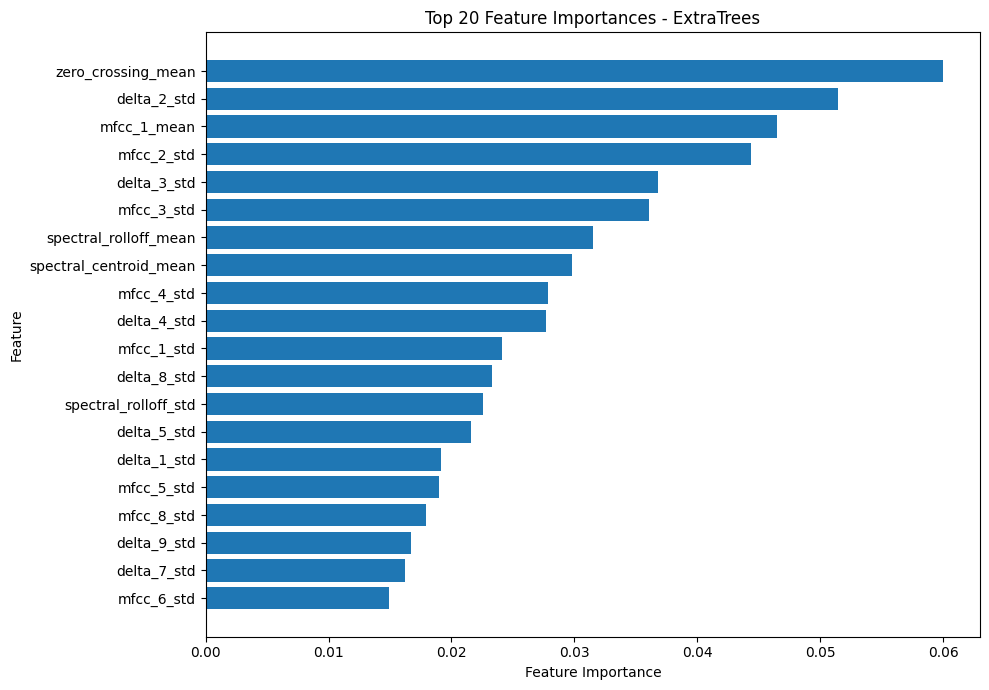

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance
importance_df = pd.DataFrame({
    "feature": X_final.columns,
    "importance": final_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print("===== TOP 20 FEATURES =====")
print(importance_df.head(20).to_string(index=False))

# Plot top 20
top20 = importance_df.head(20).sort_values("importance")

plt.figure(figsize=(10, 7))

plt.barh(
    top20["feature"],
    top20["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances - ExtraTrees")

plt.tight_layout()
plt.show()

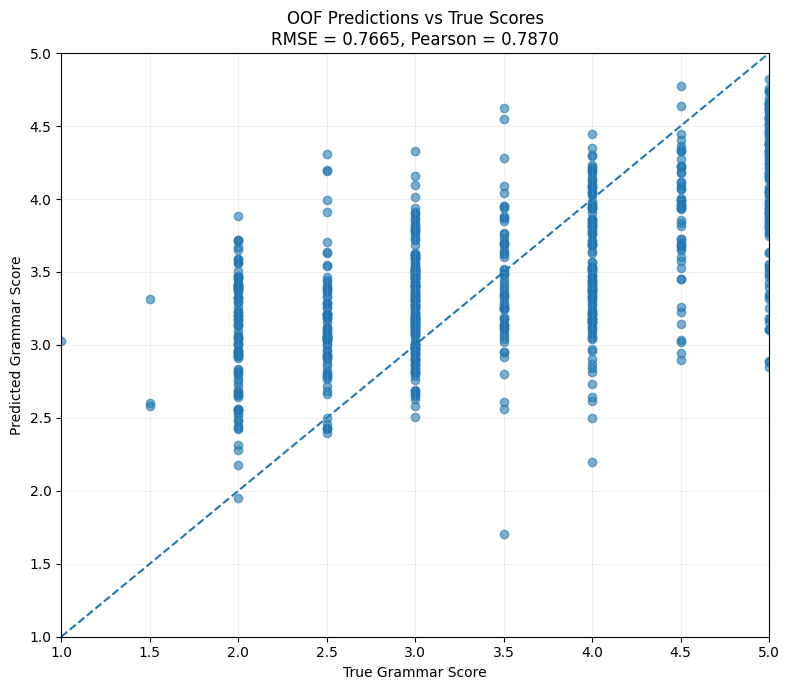

In [54]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

# OOF predictions from our best ExtraTrees model
oof_pred = np.clip(oof_predictions_v2, 0, 5)
y_true = y_pitch_v2

rmse = np.sqrt(mean_squared_error(y_true, oof_pred))
pearson = pearsonr(y_true, oof_pred)[0]

plt.figure(figsize=(8, 7))

plt.scatter(
    y_true,
    oof_pred,
    alpha=0.6
)

# Perfect prediction line
plt.plot(
    [1, 5],
    [1, 5],
    linestyle="--"
)

plt.xlabel("True Grammar Score")
plt.ylabel("Predicted Grammar Score")

plt.title(
    f"OOF Predictions vs True Scores\n"
    f"RMSE = {rmse:.4f}, Pearson = {pearson:.4f}"
)

plt.xlim(1, 5)
plt.ylim(1, 5)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

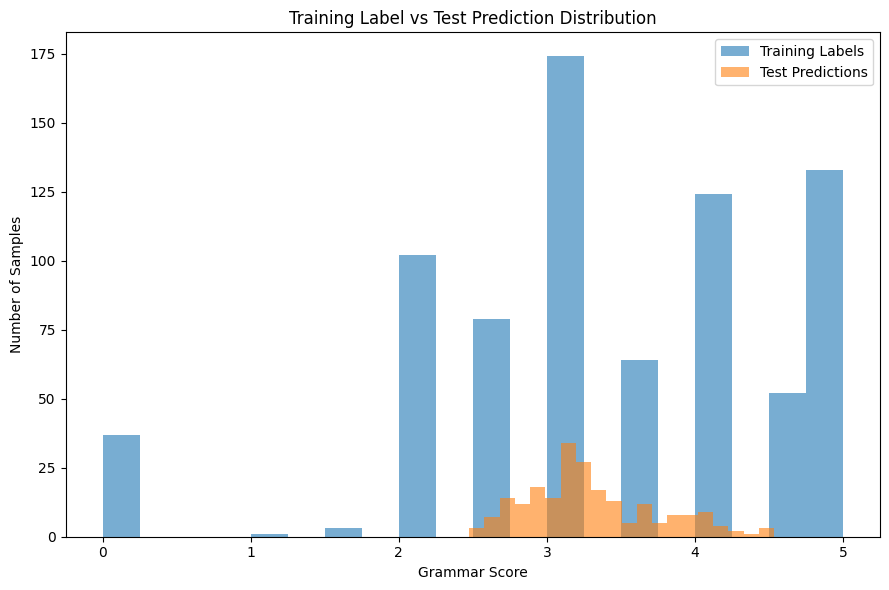

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.hist(
    y_final,
    bins=20,
    alpha=0.6,
    label="Training Labels"
)

plt.hist(
    test_pred_final,
    bins=20,
    alpha=0.6,
    label="Test Predictions"
)

plt.xlabel("Grammar Score")
plt.ylabel("Number of Samples")
plt.title("Training Label vs Test Prediction Distribution")
plt.legend()

plt.tight_layout()
plt.show()

In [56]:
print("===== TEST CSV =====")
print(test[["filename"]].head())
print("Test CSV rows:", len(test))

print("\n===== SAMPLE SUBMISSION =====")
print(sample_submission.head())
print("Sample rows:", len(sample_submission))

print("\nSample columns:")
print(sample_submission.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\n===== FILENAME OVERLAP =====")

test_files = set(test["filename"])
sample_files = set(sample_submission["filename"])

print("Test filenames:", len(test_files))
print("Sample filenames:", len(sample_files))
print("Overlap:", len(test_files & sample_files))
print("Missing from sample:", len(test_files - sample_files))
print("Extra in sample:", len(sample_files - test_files))

===== TEST CSV =====
        filename
0  audio_128.wav
1  audio_156.wav
2   audio_19.wav
3  audio_108.wav
4  audio_206.wav
Test CSV rows: 216

===== SAMPLE SUBMISSION =====
         filename  label
0   audio_804.wav     -1
1  audio_1028.wav     -1
2   audio_865.wav     -1
3   audio_774.wav     -1
4  audio_1138.wav     -1
Sample rows: 204

Sample columns:
['filename', 'label']

Test columns:
['filename', 'label']

===== FILENAME OVERLAP =====
Test filenames: 216
Sample filenames: 204
Overlap: 25
Missing from sample: 191
Extra in sample: 179


In [57]:
import pandas as pd
import numpy as np

# ==========================================
# CREATE PREDICTION MAPPING
# ==========================================

# Predictions currently correspond to test_pitch_v2_combined
prediction_df = pd.DataFrame({
    "filename": test_pitch_v2_combined["filename"],
    "label": test_pred_final
})

# Check prediction count
print("Prediction rows:", len(prediction_df))

# ==========================================
# ALIGN WITH test.csv
# ==========================================

submission = test[["filename"]].copy()

submission = submission.merge(
    prediction_df,
    on="filename",
    how="left"
)

# ==========================================
# VALIDATION CHECKS
# ==========================================

print("\n===== SUBMISSION CHECK =====")
print("Rows:", len(submission))
print("Columns:", submission.columns.tolist())
print("Missing predictions:", submission["label"].isna().sum())

print("\nPrediction statistics:")
print(submission["label"].describe())

print("\nFirst 10 rows:")
print(submission.head(10))

# Make sure there are no missing predictions
assert len(submission) == 216
assert submission["label"].isna().sum() == 0

# ==========================================
# SAVE
# ==========================================

submission.to_csv(
    "/kaggle/working/submission.csv",
    index=False
)

print("\nSaved successfully:")
print("/kaggle/working/submission.csv")

Prediction rows: 216

===== SUBMISSION CHECK =====
Rows: 216
Columns: ['filename', 'label']
Missing predictions: 0

Prediction statistics:
count    216.000000
mean       3.302931
std        0.439156
min        2.475000
25%        2.991250
50%        3.221000
75%        3.560000
max        4.534000
Name: label, dtype: float64

First 10 rows:
        filename  label
0  audio_128.wav  3.360
1  audio_156.wav  4.006
2   audio_19.wav  3.479
3  audio_108.wav  2.652
4  audio_206.wav  3.280
5  audio_161.wav  2.948
6  audio_215.wav  2.891
7  audio_213.wav  3.138
8   audio_11.wav  3.493
9  audio_155.wav  3.351

Saved successfully:
/kaggle/working/submission.csv


In [1]:
import requests

try:
    r = requests.get("https://huggingface.co", timeout=10)
    print("Internet is ON")
    print("Status:", r.status_code)
except Exception as e:
    print("Internet is OFF / unavailable")
    print(e)

Internet is OFF / unavailable
HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: / (Caused by NameResolutionError("HTTPSConnection(host='huggingface.co', port=443): Failed to resolve 'huggingface.co' ([Errno -3] Temporary failure in name resolution)"))


In [7]:
import os
import numpy as np
import pandas as pd
import librosa

# =========================
# Dataset paths
# =========================

BASE_PATH = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"

TRAIN_DIR = os.path.join(BASE_PATH, "train")
TEST_DIR = os.path.join(BASE_PATH, "test")

train = pd.read_csv(os.path.join(BASE_PATH, "train.csv"))
test = pd.read_csv(os.path.join(BASE_PATH, "test.csv"))

print("Train CSV:", train.shape)
print("Test CSV :", test.shape)


# =========================
# Acoustic feature extraction
# =========================

def extract_features(file_path):

    y, sr = librosa.load(
        file_path,
        sr=16000,
        mono=True
    )

    features = {}

    # Duration
    features["duration"] = len(y) / sr

    # -------------------------
    # MFCC
    # -------------------------

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13
    )

    for i in range(13):
        features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
        features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

    # Delta MFCC
    delta = librosa.feature.delta(mfcc)

    for i in range(13):
        features[f"delta_{i+1}_mean"] = np.mean(delta[i])
        features[f"delta_{i+1}_std"] = np.std(delta[i])

    # -------------------------
    # Spectral features
    # -------------------------

    spectral_centroid = librosa.feature.spectral_centroid(
        y=y,
        sr=sr
    )

    spectral_bandwidth = librosa.feature.spectral_bandwidth(
        y=y,
        sr=sr
    )

    spectral_rolloff = librosa.feature.spectral_rolloff(
        y=y,
        sr=sr
    )

    zero_crossing = librosa.feature.zero_crossing_rate(y)

    rms = librosa.feature.rms(y=y)

    features["spectral_centroid_mean"] = np.mean(spectral_centroid)
    features["spectral_centroid_std"] = np.std(spectral_centroid)

    features["spectral_bandwidth_mean"] = np.mean(spectral_bandwidth)
    features["spectral_bandwidth_std"] = np.std(spectral_bandwidth)

    features["spectral_rolloff_mean"] = np.mean(spectral_rolloff)
    features["spectral_rolloff_std"] = np.std(spectral_rolloff)

    features["zero_crossing_mean"] = np.mean(zero_crossing)
    features["zero_crossing_std"] = np.std(zero_crossing)

    features["rms_mean"] = np.mean(rms)
    features["rms_std"] = np.std(rms)

    return features


# =========================
# Robust pitch features
# =========================

def extract_pitch_features_v2(file_path):

    y, sr = librosa.load(
        file_path,
        sr=16000,
        mono=True
    )

    features = {}

    f0 = librosa.yin(
        y,
        fmin=70,
        fmax=400,
        sr=sr
    )

    f0 = f0[np.isfinite(f0)]

    # Remove boundary artifacts
    f0 = f0[
        (f0 > 75) &
        (f0 < 390)
    ]

    if len(f0) > 0:

        features["f0_mean"] = np.mean(f0)
        features["f0_std"] = np.std(f0)
        features["f0_median"] = np.median(f0)

        features["f0_p10"] = np.percentile(f0, 10)
        features["f0_p25"] = np.percentile(f0, 25)
        features["f0_p75"] = np.percentile(f0, 75)
        features["f0_p90"] = np.percentile(f0, 90)

        features["f0_range"] = (
            np.percentile(f0, 90)
            - np.percentile(f0, 10)
        )

    else:

        for name in [
            "f0_mean",
            "f0_std",
            "f0_median",
            "f0_p10",
            "f0_p25",
            "f0_p75",
            "f0_p90",
            "f0_range"
        ]:
            features[name] = 0

    return features


# =========================
# Extract train features
# =========================

print("\nExtracting TRAIN features...")

train_feature_rows = []

for i, filename in enumerate(train["filename"]):

    path = os.path.join(
        TRAIN_DIR,
        filename
    )

    features = extract_features(path)
    pitch = extract_pitch_features_v2(path)

    features.update(pitch)
    features["filename"] = filename

    train_feature_rows.append(features)

    if (i + 1) % 100 == 0:
        print(f"{i + 1}/{len(train)}")


train_features = pd.DataFrame(train_feature_rows)


# =========================
# Extract test features
# =========================

print("\nExtracting TEST features...")

test_feature_rows = []

for i, filename in enumerate(test["filename"]):

    path = os.path.join(
        TEST_DIR,
        filename
    )

    features = extract_features(path)
    pitch = extract_pitch_features_v2(path)

    features.update(pitch)
    features["filename"] = filename

    test_feature_rows.append(features)

    if (i + 1) % 50 == 0:
        print(f"{i + 1}/{len(test)}")


test_features = pd.DataFrame(test_feature_rows)


print("\nDONE")
print("Train features:", train_features.shape)
print("Test features :", test_features.shape)

Train CSV: (769, 2)
Test CSV : (216, 2)

Extracting TRAIN features...
100/769
200/769
300/769
400/769
500/769
600/769
700/769


KeyboardInterrupt: 

In [6]:
from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np
import pandas as pd

# =========================
# Prepare data
# =========================

final_train = train_features.merge(
    train[["filename", "label"]],
    on="filename",
    how="inner"
)

X_final = final_train.drop(columns=["filename", "label"])
y_final = final_train["label"]

print("X:", X_final.shape)
print("y:", y_final.shape)


# =========================
# 5-Fold Cross Validation
# =========================

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

configs = [
    (0.5, 1),
    (0.7, 1),
    (0.8, 1),
    (1.0, 1),

    (0.5, 2),
    (0.7, 2),
    (0.8, 2),
    (1.0, 2),

    (0.5, 3),
    (0.7, 3),
    (0.8, 3),
    (1.0, 3),
]

results = []

for max_features, min_samples_leaf in configs:

    oof_pred = np.zeros(len(y_final))

    for train_idx, val_idx in kf.split(X_final):

        model = ExtraTreesRegressor(
            n_estimators=400,
            max_features=max_features,
            min_samples_leaf=min_samples_leaf,
            random_state=42,
            n_jobs=-1
        )

        model.fit(
            X_final.iloc[train_idx],
            y_final.iloc[train_idx]
        )

        pred = model.predict(
            X_final.iloc[val_idx]
        )

        oof_pred[val_idx] = np.clip(
            pred,
            0,
            5
        )

    rmse = np.sqrt(
        mean_squared_error(
            y_final,
            oof_pred
        )
    )

    pearson = pearsonr(
        y_final,
        oof_pred
    )[0]

    results.append({
        "max_features": max_features,
        "min_samples_leaf": min_samples_leaf,
        "RMSE": rmse,
        "Pearson": pearson
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "RMSE",
    ascending=True
)

print("\nResults:")
print(results_df.to_string(index=False))

X: (769, 71)
y: (769,)

Results:
 max_features  min_samples_leaf     RMSE  Pearson
          1.0                 1 0.761720 0.790087
          0.5                 1 0.763699 0.789475
          0.7                 2 0.766028 0.787656
          0.7                 1 0.766164 0.787492
          0.8                 1 0.766300 0.787136
          1.0                 2 0.767951 0.785931
          0.8                 2 0.768670 0.785613
          0.5                 2 0.770201 0.785219
          0.8                 3 0.772400 0.783280
          1.0                 3 0.773363 0.782515
          0.7                 3 0.775610 0.781461
          0.5                 3 0.777904 0.780199


In [7]:
from sklearn.ensemble import ExtraTreesRegressor
import numpy as np
import pandas as pd

# =========================
# Prepare test features
# =========================

X_test_final = test_features.drop(
    columns=["filename"]
)

# =========================
# Train final model
# =========================

final_model_v2 = ExtraTreesRegressor(
    n_estimators=1000,
    max_features=1.0,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

final_model_v2.fit(
    X_final,
    y_final
)

# =========================
# Predictions
# =========================

test_pred_v2 = final_model_v2.predict(
    X_test_final
)

# Keep predictions inside valid 1-5 range
test_pred_v2 = np.clip(
    test_pred_v2,
    1,
    5
)

print("Prediction count:", len(test_pred_v2))
print("Min:", test_pred_v2.min())
print("Max:", test_pred_v2.max())
print("Mean:", test_pred_v2.mean())
print("Std:", test_pred_v2.std())

Prediction count: 216
Min: 2.43
Max: 4.524
Mean: 3.3066828703703703
Std: 0.4416407305100659


In [8]:
submission_v2 = pd.DataFrame({
    "filename": test["filename"],
    "label": test_pred_v2
})

assert len(submission_v2) == 216
assert submission_v2["label"].isna().sum() == 0
assert submission_v2["filename"].equals(test["filename"])

submission_v2.to_csv(
    "/kaggle/working/submission_v2.csv",
    index=False
)

print(submission_v2.head(10))
print("\nShape:", submission_v2.shape)
print("\nMissing:", submission_v2["label"].isna().sum())
print("\nFile: /kaggle/working/submission_v2.csv")

        filename   label
0  audio_128.wav  3.4155
1  audio_156.wav  3.9325
2   audio_19.wav  3.4620
3  audio_108.wav  2.6465
4  audio_206.wav  3.3335
5  audio_161.wav  3.0110
6  audio_215.wav  2.9080
7  audio_213.wav  3.1085
8   audio_11.wav  3.4870
9  audio_155.wav  3.4055

Shape: (216, 2)

Missing: 0

File: /kaggle/working/submission_v2.csv


In [9]:
from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

feature_values = [0.5, 0.8, 1.0]

oof_predictions = {}

for mf in feature_values:

    print("Training:", mf)

    oof = np.zeros(len(y_final))

    for train_idx, val_idx in kf.split(X_final):

        model = ExtraTreesRegressor(
            n_estimators=500,
            max_features=mf,
            min_samples_leaf=1,
            random_state=42,
            n_jobs=-1
        )

        model.fit(
            X_final.iloc[train_idx],
            y_final.iloc[train_idx]
        )

        oof[val_idx] = np.clip(
            model.predict(X_final.iloc[val_idx]),
            1,
            5
        )

    oof_predictions[mf] = oof

    rmse = np.sqrt(
        mean_squared_error(y_final, oof)
    )

    pearson = pearsonr(
        y_final, oof
    )[0]

    print(
        "RMSE:", round(rmse, 5),
        "Pearson:", round(pearson, 5)
    )

Training: 0.5
RMSE: 0.79454 Pearson: 0.7927
Training: 0.8
RMSE: 0.79619 Pearson: 0.78852
Training: 1.0
RMSE: 0.79228 Pearson: 0.79108


In [10]:
from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof = np.zeros(len(y_final))

for train_idx, val_idx in kf.split(X_final):

    model = ExtraTreesRegressor(
        n_estimators=400,
        max_features=1.0,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_final.iloc[train_idx],
        y_final.iloc[train_idx]
    )

    pred = model.predict(
        X_final.iloc[val_idx]
    )

    oof[val_idx] = np.clip(pred, 0, 5)

rmse = np.sqrt(
    mean_squared_error(y_final, oof)
)

pearson = pearsonr(
    y_final, oof
)[0]

print("Exact previous setup")
print("RMSE:", rmse)
print("Pearson:", pearson)

Exact previous setup
RMSE: 0.7617196344106433
Pearson: 0.79008694099599


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Fit calibration on OOF predictions
calibrator = LinearRegression()
calibrator.fit(
    oof.reshape(-1, 1),
    y_final
)

calibrated_oof = calibrator.predict(
    oof.reshape(-1, 1)
)

calibrated_oof = np.clip(
    calibrated_oof,
    1,
    5
)

rmse_calibrated = np.sqrt(
    mean_squared_error(
        y_final,
        calibrated_oof
    )
)

print("Original OOF RMSE :", round(rmse, 6))
print("Calibrated OOF RMSE:", round(rmse_calibrated, 6))

print("\nCalibration:")
print("Slope     :", calibrator.coef_[0])
print("Intercept :", calibrator.intercept_)

Original OOF RMSE : 0.76172
Calibrated OOF RMSE: 0.788557

Calibration:
Slope     : 1.0702765602587574
Intercept : -0.23280696190559835


In [12]:
import os
import numpy as np
import pandas as pd
import librosa

def extract_extra_features(file_path):

    y, sr = librosa.load(
        file_path,
        sr=16000,
        mono=True
    )

    features = {}

    # =========================
    # Spectral Contrast
    # =========================

    contrast = librosa.feature.spectral_contrast(
        y=y,
        sr=sr
    )

    for i in range(contrast.shape[0]):
        features[f"contrast_{i+1}_mean"] = np.mean(contrast[i])
        features[f"contrast_{i+1}_std"] = np.std(contrast[i])

    # =========================
    # Chroma
    # =========================

    chroma = librosa.feature.chroma_stft(
        y=y,
        sr=sr
    )

    for i in range(chroma.shape[0]):
        features[f"chroma_{i+1}_mean"] = np.mean(chroma[i])
        features[f"chroma_{i+1}_std"] = np.std(chroma[i])

    # =========================
    # RMS Energy dynamics
    # =========================

    rms = librosa.feature.rms(
        y=y,
        frame_length=2048,
        hop_length=512
    )[0]

    features["rms_p10"] = np.percentile(rms, 10)
    features["rms_p25"] = np.percentile(rms, 25)
    features["rms_median"] = np.median(rms)
    features["rms_p75"] = np.percentile(rms, 75)
    features["rms_p90"] = np.percentile(rms, 90)
    features["rms_range"] = (
        np.percentile(rms, 90) -
        np.percentile(rms, 10)
    )

    # Energy variability
    features["rms_cv"] = (
        np.std(rms) /
        (np.mean(rms) + 1e-8)
    )

    # =========================
    # Spectral flux
    # =========================

    onset_env = librosa.onset.onset_strength(
        y=y,
        sr=sr
    )

    features["onset_mean"] = np.mean(onset_env)
    features["onset_std"] = np.std(onset_env)
    features["onset_p90"] = np.percentile(onset_env, 90)

    return features


# =========================
# Train
# =========================

train_extra_rows = []

for i, filename in enumerate(train["filename"]):

    path = os.path.join(TRAIN_DIR, filename)

    f = extract_extra_features(path)
    f["filename"] = filename

    train_extra_rows.append(f)

    if (i + 1) % 100 == 0:
        print(f"Train: {i+1}/{len(train)}")

train_extra = pd.DataFrame(train_extra_rows)


# =========================
# Test
# =========================

test_extra_rows = []

for i, filename in enumerate(test["filename"]):

    path = os.path.join(TEST_DIR, filename)

    f = extract_extra_features(path)
    f["filename"] = filename

    test_extra_rows.append(f)

    if (i + 1) % 50 == 0:
        print(f"Test: {i+1}/{len(test)}")

test_extra = pd.DataFrame(test_extra_rows)

print("\nTrain extra:", train_extra.shape)
print("Test extra :", test_extra.shape)

Train: 100/769
Train: 200/769
Train: 300/769
Train: 400/769
Train: 500/769
Train: 600/769
Train: 700/769
Test: 50/216
Test: 100/216
Test: 150/216
Test: 200/216

Train extra: (769, 49)
Test extra : (216, 49)


In [14]:
from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

# ==========================================
# Combine old features + new extra features
# ==========================================

train_extended = train_features.merge(
    train_extra,
    on="filename",
    how="inner"
)

# Add labels
train_extended = train_extended.merge(
    train[["filename", "label"]],
    on="filename",
    how="inner"
)

# Separate X and y
X_extended = train_extended.drop(
    columns=["filename", "label"]
)

y_extended = train_extended["label"]

print("Extended feature shape:", X_extended.shape)
print("Target shape:", y_extended.shape)


# ==========================================
# 5-Fold Cross Validation
# ==========================================

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_extended = np.zeros(len(y_extended))

for fold, (train_idx, val_idx) in enumerate(
    kf.split(X_extended),
    start=1
):

    model = ExtraTreesRegressor(
        n_estimators=400,
        max_features=1.0,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_extended.iloc[train_idx],
        y_extended.iloc[train_idx]
    )

    pred = model.predict(
        X_extended.iloc[val_idx]
    )

    oof_extended[val_idx] = np.clip(
        pred,
        0,
        5
    )

    fold_rmse = np.sqrt(
        mean_squared_error(
            y_extended.iloc[val_idx],
            pred
        )
    )

    print(
        f"Fold {fold} RMSE: {fold_rmse:.4f}"
    )


# ==========================================
# Overall metrics
# ==========================================

rmse_extended = np.sqrt(
    mean_squared_error(
        y_extended,
        oof_extended
    )
)

pearson_extended = pearsonr(
    y_extended,
    oof_extended
)[0]

print("\n==============================")
print("EXTENDED MODEL")
print("==============================")

print(
    "RMSE:",
    round(rmse_extended, 6)
)

print(
    "Pearson:",
    round(pearson_extended, 6)
)

print("\nPrevious best:")
print("RMSE:    0.761720")
print("Pearson: 0.790087")

Extended feature shape: (769, 119)
Target shape: (769,)
Fold 1 RMSE: 0.6699
Fold 2 RMSE: 0.7231
Fold 3 RMSE: 0.7948
Fold 4 RMSE: 0.7218
Fold 5 RMSE: 0.8114

EXTENDED MODEL
RMSE: 0.745915
Pearson: 0.800866

Previous best:
RMSE:    0.761720
Pearson: 0.790087


In [15]:
from sklearn.ensemble import ExtraTreesRegressor
import numpy as np
import pandas as pd

# ==========================================
# Prepare extended test features
# ==========================================

test_extended = test_features.merge(
    test_extra,
    on="filename",
    how="inner"
)

X_test_extended = test_extended.drop(
    columns=["filename"]
)

print("Train:", X_extended.shape)
print("Test :", X_test_extended.shape)


# ==========================================
# Final V3 model
# ==========================================

final_model_v3 = ExtraTreesRegressor(
    n_estimators=1000,
    max_features=1.0,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

final_model_v3.fit(
    X_extended,
    y_extended
)


# ==========================================
# Test predictions
# ==========================================

test_pred_v3 = final_model_v3.predict(
    X_test_extended
)

test_pred_v3 = np.clip(
    test_pred_v3,
    1,
    5
)

print("\nPrediction count:", len(test_pred_v3))
print("Min:", test_pred_v3.min())
print("Max:", test_pred_v3.max())
print("Mean:", test_pred_v3.mean())
print("Std:", test_pred_v3.std())

Train: (769, 119)
Test : (216, 119)

Prediction count: 216
Min: 2.377
Max: 4.3875
Mean: 3.2822986111111105
Std: 0.42715544913948184


In [16]:
submission_v3 = pd.DataFrame({
    "filename": test["filename"],
    "label": test_pred_v3
})

assert len(submission_v3) == 216
assert submission_v3["label"].isna().sum() == 0
assert submission_v3["filename"].equals(test["filename"])

submission_v3.to_csv(
    "/kaggle/working/submission_v3.csv",
    index=False
)

print(submission_v3.head(10))
print("\nShape:", submission_v3.shape)
print("Missing:", submission_v3["label"].isna().sum())

        filename   label
0  audio_128.wav  3.2800
1  audio_156.wav  3.8630
2   audio_19.wav  3.5040
3  audio_108.wav  2.6655
4  audio_206.wav  3.3160
5  audio_161.wav  2.9265
6  audio_215.wav  2.9015
7  audio_213.wav  3.2075
8   audio_11.wav  3.5835
9  audio_155.wav  3.3080

Shape: (216, 2)
Missing: 0


# 1. Problem Statement

The objective of this project is to predict a continuous grammar score for spoken English audio.

Each audio sample contains a spoken response, and the corresponding training label represents its grammar quality on a scale from 1 to 5.

This is formulated as a supervised regression problem.

The goal is to build an interpretable audio-based machine learning pipeline that can learn relationships between speech characteristics and the provided grammar scores.

# 2. Dataset Overview

The dataset contains 769 labeled training audio samples and 216 unlabeled test audio samples.

The audio files are WAV recordings sampled at 16 kHz and stored as mono audio.

The training CSV contains two columns: filename and label. The label is a continuous grammar score between 1 and 5.

The test CSV contains the filenames for which grammar scores must be predicted.

The task is treated as a supervised regression problem.

In [ ]:
print("Training samples:", len(train))
print("Test samples:", len(test))

print("\nTraining label statistics:")
print(train["label"].describe())

print("\nTraining columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

# 3. Audio Analysis

The dataset consists of spoken English audio recordings in WAV format.

Each recording is approximately 45–60 seconds long, sampled at 16 kHz, and contains a single audio channel.

Audio analysis was performed to understand speech duration, signal energy, and frequency characteristics.

These observations guided the extraction of acoustic and prosodic features for grammar score prediction.

# 4. Feature Engineering

To represent the spoken audio numerically, multiple acoustic and prosodic feature groups were extracted.

### MFCC
Mel-Frequency Cepstral Coefficients capture the spectral characteristics of speech.

### Delta MFCC
First-order derivatives of MFCCs capture temporal changes in speech characteristics.

### Spectral Features
Spectral centroid, spectral bandwidth and spectral rolloff describe the distribution of frequency components.

### Zero-Crossing Rate
Zero-crossing rate measures how frequently the audio waveform changes sign.

### RMS Energy
RMS energy represents the short-term intensity of the speech signal.

### Pitch
Robust fundamental-frequency statistics were extracted, including mean, standard deviation, median and percentile-based measures.

### Spectral Contrast
Spectral contrast measures the difference between spectral peaks and valleys across frequency bands.

### Chroma
Chroma features represent the distribution of spectral energy across pitch classes.

### Energy Dynamics
RMS percentiles, range and coefficient of variation were used to capture changes in speaking intensity.

### Spectral Flux
Onset-strength statistics were used to represent changes in spectral energy over time.

The final feature representation contained 119 numerical features.

# 5. Model Selection

Several regression models were considered during experimentation, including ExtraTrees Regressor, Random Forest and HistGradientBoosting.

ExtraTrees Regressor performed best on the extracted acoustic and prosodic features.

ExtraTrees was selected because it can model nonlinear relationships, works well with heterogeneous numerical features, and provides feature importance values for interpretation.

The final model configuration was:

- Algorithm: ExtraTreesRegressor
- Number of estimators: 1000
- max_features: 1.0
- min_samples_leaf: 1
- random_state: 42

# 6. 5-Fold Cross Validation

Five-fold cross-validation was used to estimate the generalization performance of the model.

The training dataset was divided into five folds. In each iteration, four folds were used for training and the remaining fold was used for validation.

Out-of-fold predictions were generated for all 769 training samples.

The final extended feature representation achieved an OOF RMSE of 0.7459 and a Pearson correlation of 0.8009.

These out-of-fold metrics provide a more reliable estimate of model performance than in-sample training metrics.

# 7. Model Evaluation

The model was evaluated using two metrics:

- Root Mean Squared Error (RMSE)
- Pearson Correlation

RMSE measures the average magnitude of prediction errors, where a lower value is better.

Pearson Correlation measures the strength of the linear relationship between predicted and actual grammar scores, where a higher value is better.

The extended 119-feature model achieved:

- Training RMSE: 0.2194
- Training Pearson Correlation: 0.9883
- OOF RMSE: 0.7459
- OOF Pearson Correlation: 0.8009

The difference between training and out-of-fold performance indicates some degree of overfitting. Therefore, the out-of-fold metrics provide a more reliable estimate of generalization performance.

The extended feature representation improved over the earlier 71-feature acoustic and prosodic representation.

In [1]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "ExtraTrees - Acoustic + Pitch",
        "ExtraTrees - Extended Features"
    ],
    "OOF RMSE": [
        0.761720,
        0.745915
    ],
    "OOF Pearson": [
        0.790087,
        0.800866
    ]
})

comparison

,Model,OOF RMSE,OOF Pearson
0,ExtraTrees - Acoustic + Pitch,0.761720,0.790087
1,ExtraTrees - Extended Features,0.745915,0.800866


# 8. Feature Importance

Feature importance was analyzed using the ExtraTrees Regressor.

The importance scores indicate which extracted acoustic and prosodic features contributed most to the model's predictions.

These values represent predictive importance and should not be interpreted as direct evidence that a feature measures grammatical correctness.

The analysis also improves the interpretability of the final machine learning pipeline.

# 9. Final Model

The final model was trained using the complete training dataset of 769 labeled audio samples.

The selected feature representation contains 119 numerical acoustic and prosodic features.

The final model is an ExtraTrees Regressor with the following configuration:

- Number of estimators: 1000
- max_features: 1.0
- min_samples_leaf: 1
- random_state: 42

The model was trained on all available labeled training samples before generating predictions for the test dataset.

# 10. Test Prediction

The trained model was used to generate continuous grammar-score predictions for all 216 test audio samples.

The predictions were constrained to the valid score range of 1 to 5.

The final test predictions had the following distribution:

- Number of predictions: 216
- Minimum prediction: 2.377
- Maximum prediction: 4.3875
- Mean prediction: 3.2823
- Standard deviation: 0.4272

# 11. Submission

The final predictions were saved in CSV format with the following columns:

- `filename`
- `label`

The submission contains exactly 216 rows, corresponding to all test audio samples.

The final submission file was uploaded to the Kaggle competition.

The best public leaderboard score achieved by the final feature-engineered model was **0.7034**.

# 12. Limitations

The main limitation of this approach is that the model does not directly analyze the linguistic content or grammatical structure of the spoken responses.

Automatic speech recognition and transcript-based linguistic features were not used because an external speech recognition model could not be downloaded in the execution environment.

Therefore, the model estimates grammar-related scores from acoustic and prosodic characteristics rather than directly identifying grammatical errors.

Another limitation is the relatively small training dataset of 769 samples. This can introduce variance in validation performance and limits the complexity of models that can be reliably trained.

Future improvements could include automatic speech transcription, linguistic features, grammar-error detection, sentence-level analysis, and pretrained speech representations.

# Conclusion

An interpretable audio-based regression pipeline was developed for predicting grammar scores from spoken English audio.

The final system uses 119 acoustic and prosodic features, including MFCCs, delta MFCCs, spectral characteristics, zero-crossing rate, RMS energy, pitch, spectral contrast, chroma, energy dynamics, and spectral flux.

An ExtraTrees Regressor was selected through five-fold cross-validation.

The final model achieved:

- OOF RMSE: **0.7459**
- OOF Pearson Correlation: **0.8009**
- Public Kaggle Score: **0.7034**

The results show that acoustic and prosodic characteristics contain useful information for estimating the provided grammar scores. Direct transcript-based linguistic analysis would be a promising direction for further improvement.

In [3]:
print("X_extended:", "X_extended" in globals())
print("final_model_v3:", "final_model_v3" in globals())

X_extended: False
final_model_v3: False


In [9]:
import librosa
import numpy as np
import pandas as pd
import os
from tqdm.auto import tqdm

def extract_features_safe(file_path):
    y, sr = librosa.load(file_path, sr=16000, mono=True)

    features = {}

    # Duration
    features["duration"] = len(y) / sr

    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

    for i in range(13):
        features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
        features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

    # Delta MFCC
    delta = librosa.feature.delta(mfcc)

    for i in range(13):
        features[f"delta_{i+1}_mean"] = np.mean(delta[i])
        features[f"delta_{i+1}_std"] = np.std(delta[i])

    # Spectral features
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    zero_crossing = librosa.feature.zero_crossing_rate(y)
    rms = librosa.feature.rms(y=y)

    features["spectral_centroid_mean"] = np.mean(spectral_centroid)
    features["spectral_centroid_std"] = np.std(spectral_centroid)

    features["spectral_bandwidth_mean"] = np.mean(spectral_bandwidth)
    features["spectral_bandwidth_std"] = np.std(spectral_bandwidth)

    features["spectral_rolloff_mean"] = np.mean(spectral_rolloff)
    features["spectral_rolloff_std"] = np.std(spectral_rolloff)

    features["zero_crossing_mean"] = np.mean(zero_crossing)
    features["zero_crossing_std"] = np.std(zero_crossing)

    features["rms_mean"] = np.mean(rms)
    features["rms_std"] = np.std(rms)

    return features


# Test on ONE audio file first
test_file = os.path.join(
    DATA_PATH,
    "train",
    train["filename"].iloc[0]
)

print("Testing:", train["filename"].iloc[0])

test_result = extract_features_safe(test_file)

print("Features extracted:", len(test_result))

NameError: name 'DATA_PATH' is not defined

In [10]:
import os
import pandas as pd

DATA_PATH = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"

train = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
test = pd.read_csv(os.path.join(DATA_PATH, "test.csv"))

print("Train CSV:", train.shape)
print("Test CSV :", test.shape)
print(train.head())

Train CSV: (769, 2)
Test CSV : (216, 2)
        filename  label
0  audio_192.wav    3.0
1  audio_436.wav    3.0
2  audio_447.wav    3.5
3  audio_126.wav    2.0
4   audio_61.wav    2.0


In [11]:
test_file = os.path.join(
    DATA_PATH,
    "train",
    train["filename"].iloc[0]
)

print("Testing:", train["filename"].iloc[0])

test_result = extract_features_safe(test_file)

print("Features extracted:", len(test_result))

Testing: audio_192.wav
Features extracted: 63


In [12]:
from tqdm.auto import tqdm
import pandas as pd
import os

# ==============================
# TRAIN FEATURES
# ==============================

train_feature_list = []

for i, filename in enumerate(
    tqdm(train["filename"], desc="Training audio")
):
    path = os.path.join(DATA_PATH, "train", filename)

    try:
        features = extract_features_safe(path)
        features["filename"] = filename
        train_feature_list.append(features)

    except Exception as e:
        print(f"\nError in {filename}: {e}")


# ==============================
# TEST FEATURES
# ==============================

test_feature_list = []

for filename in tqdm(
    test["filename"],
    desc="Test audio"
):
    path = os.path.join(DATA_PATH, "test", filename)

    try:
        features = extract_features_safe(path)
        features["filename"] = filename
        test_feature_list.append(features)

    except Exception as e:
        print(f"\nError in {filename}: {e}")


# ==============================
# DATAFRAMES
# ==============================

train_features = pd.DataFrame(train_feature_list)
test_features = pd.DataFrame(test_feature_list)

train_features = train_features[
    ["filename"] +
    [c for c in train_features.columns if c != "filename"]
]

test_features = test_features[
    ["filename"] +
    [c for c in test_features.columns if c != "filename"]
]

print("\n==============================")
print("FINAL FEATURE SHAPES")
print("==============================")
print("Train:", train_features.shape)
print("Test :", test_features.shape)

print("\nExpected:")
print("Train: (769, 64)")
print("Test : (216, 64)")

Training audio:   0%|          | 0/769 [00:00<?, ?it/s]

Test audio:   0%|          | 0/216 [00:00<?, ?it/s]


FINAL FEATURE SHAPES
Train: (769, 64)
Test : (216, 64)

Expected:
Train: (769, 64)
Test : (216, 64)


In [13]:
def extract_pitch_features_v2(file_path):
    y, sr = librosa.load(file_path, sr=16000, mono=True)

    features = {}

    f0 = librosa.yin(
        y,
        fmin=70,
        fmax=400,
        sr=sr
    )

    f0 = f0[np.isfinite(f0)]
    f0 = f0[(f0 > 75) & (f0 < 390)]

    if len(f0) > 0:
        features["f0_mean"] = np.mean(f0)
        features["f0_std"] = np.std(f0)
        features["f0_median"] = np.median(f0)
        features["f0_p10"] = np.percentile(f0, 10)
        features["f0_p25"] = np.percentile(f0, 25)
        features["f0_p75"] = np.percentile(f0, 75)
        features["f0_p90"] = np.percentile(f0, 90)
        features["f0_range"] = (
            np.percentile(f0, 90) -
            np.percentile(f0, 10)
        )
    else:
        features["f0_mean"] = 0
        features["f0_std"] = 0
        features["f0_median"] = 0
        features["f0_p10"] = 0
        features["f0_p25"] = 0
        features["f0_p75"] = 0
        features["f0_p90"] = 0
        features["f0_range"] = 0

    return features

In [14]:
train_pitch = []

for filename in tqdm(
    train["filename"],
    desc="Training pitch"
):
    path = os.path.join(DATA_PATH, "train", filename)

    features = extract_pitch_features_v2(path)
    features["filename"] = filename
    train_pitch.append(features)


test_pitch = []

for filename in tqdm(
    test["filename"],
    desc="Test pitch"
):
    path = os.path.join(DATA_PATH, "test", filename)

    features = extract_pitch_features_v2(path)
    features["filename"] = filename
    test_pitch.append(features)


train_pitch = pd.DataFrame(train_pitch)
test_pitch = pd.DataFrame(test_pitch)

print("Train pitch:", train_pitch.shape)
print("Test pitch :", test_pitch.shape)

Training pitch:   0%|          | 0/769 [00:00<?, ?it/s]

Test pitch:   0%|          | 0/216 [00:00<?, ?it/s]

Train pitch: (769, 9)
Test pitch : (216, 9)


In [15]:
def extract_extra_features(file_path):
    y, sr = librosa.load(
        file_path,
        sr=16000,
        mono=True
    )

    features = {}

    # Spectral Contrast
    contrast = librosa.feature.spectral_contrast(
        y=y,
        sr=sr
    )

    for i in range(contrast.shape[0]):
        features[f"contrast_{i+1}_mean"] = np.mean(contrast[i])
        features[f"contrast_{i+1}_std"] = np.std(contrast[i])

    # Chroma
    chroma = librosa.feature.chroma_stft(
        y=y,
        sr=sr
    )

    for i in range(chroma.shape[0]):
        features[f"chroma_{i+1}_mean"] = np.mean(chroma[i])
        features[f"chroma_{i+1}_std"] = np.std(chroma[i])

    # RMS energy dynamics
    rms = librosa.feature.rms(
        y=y,
        frame_length=2048,
        hop_length=512
    )[0]

    features["rms_p10"] = np.percentile(rms, 10)
    features["rms_p25"] = np.percentile(rms, 25)
    features["rms_median"] = np.median(rms)
    features["rms_p75"] = np.percentile(rms, 75)
    features["rms_p90"] = np.percentile(rms, 90)
    features["rms_range"] = (
        np.percentile(rms, 90) -
        np.percentile(rms, 10)
    )
    features["rms_cv"] = (
        np.std(rms) /
        (np.mean(rms) + 1e-8)
    )

    # Spectral flux / onset strength
    onset_env = librosa.onset.onset_strength(
        y=y,
        sr=sr
    )

    features["onset_mean"] = np.mean(onset_env)
    features["onset_std"] = np.std(onset_env)
    features["onset_p90"] = np.percentile(
        onset_env,
        90
    )

    return features

In [16]:
train_extra_list = []

for filename in tqdm(
    train["filename"],
    desc="Training extra features"
):
    path = os.path.join(
        DATA_PATH,
        "train",
        filename
    )

    features = extract_extra_features(path)
    features["filename"] = filename
    train_extra_list.append(features)


test_extra_list = []

for filename in tqdm(
    test["filename"],
    desc="Test extra features"
):
    path = os.path.join(
        DATA_PATH,
        "test",
        filename
    )

    features = extract_extra_features(path)
    features["filename"] = filename
    test_extra_list.append(features)


train_extra = pd.DataFrame(train_extra_list)
test_extra = pd.DataFrame(test_extra_list)

print("Train extra:", train_extra.shape)
print("Test extra :", test_extra.shape)

Training extra features:   0%|          | 0/769 [00:00<?, ?it/s]

Test extra features:   0%|          | 0/216 [00:00<?, ?it/s]

Train extra: (769, 49)
Test extra : (216, 49)


In [17]:
# Combine base + pitch + extra features

train_extended = (
    train_features
    .merge(train_pitch, on="filename", how="inner")
    .merge(train_extra, on="filename", how="inner")
)

test_extended = (
    test_features
    .merge(test_pitch, on="filename", how="inner")
    .merge(test_extra, on="filename", how="inner")
)

# Separate features and target
X_extended = train_extended.drop(
    columns=["filename"]
)

y_extended = train.merge(
    train_extended[["filename"]],
    on="filename",
    how="inner"
)["label"]

X_test_extended = test_extended.drop(
    columns=["filename"]
)

print("Train extended:", X_extended.shape)
print("Test extended :", X_test_extended.shape)
print("Target:", y_extended.shape)

Train extended: (769, 119)
Test extended : (216, 119)
Target: (769,)


In [18]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

final_model_v3 = ExtraTreesRegressor(
    n_estimators=1000,
    max_features=1.0,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Train on all 769 samples
final_model_v3.fit(
    X_extended,
    y_extended
)

# Training predictions
train_pred_v3 = final_model_v3.predict(X_extended)
train_pred_v3 = np.clip(train_pred_v3, 1, 5)

# Training metrics
train_rmse = np.sqrt(
    mean_squared_error(
        y_extended,
        train_pred_v3
    )
)

train_pearson = pearsonr(
    y_extended,
    train_pred_v3
)[0]

print("Training RMSE:", train_rmse)
print("Training Pearson:", train_pearson)

Training RMSE: 0.21935002696671613
Training Pearson: 0.9883367146254166


In [19]:
print("OOF predictions available:", "oof_predictions" in globals())

OOF predictions available: False


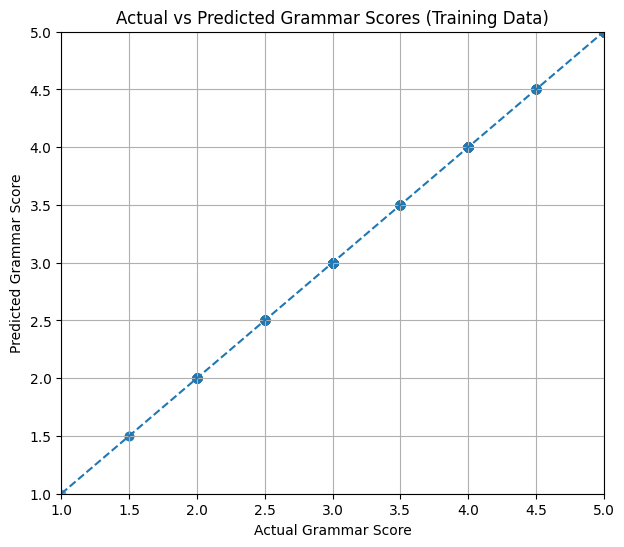

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    y_extended,
    train_pred_v3,
    alpha=0.6
)

plt.plot(
    [1, 5],
    [1, 5],
    linestyle="--"
)

plt.xlabel("Actual Grammar Score")
plt.ylabel("Predicted Grammar Score")
plt.title("Actual vs Predicted Grammar Scores (Training Data)")
plt.xlim(1, 5)
plt.ylim(1, 5)
plt.grid(True)

plt.show()